# MBG Smart Plate: Sistem Personalisasi Menu Gizi Berbasis Web untuk Mendukung Program Makan Bergizi Gratis

## Problem Discovery

**Latar Belakang:**
Program Makan Bergizi Gratis (MBG) menghadapi tantangan dalam personalisasi gizi. Saat ini, sistem cenderung memberikan menu generik tanpa mempertimbangkan kondisi fisik unik setiap siswa (stunting, gizi normal, atau overweight). Solusi yang ditawarkan adalah sistem personalisasi menu otomatis berdasarkan klasifikasi kondisi fisik berdasarkan status gizi siswa.

- Problem 1 (Fitur Gizi Signifikan): Apa saja parameter gizi yang paling berpengaruh/sebaiknya dijadikan patokan utama dalam menyusun rekomendasi menu personalisasi untuk siswa dengan status gizi berbeda?

- Problem 2 (Fitur Dominan): Variabel apa yang paling dominan mempengaruhi klasifikasi status gizi siswa?

- Problem 3 (Distribusi dan Prevalensi): Bagaimana distribusi status gizi siswa? Berapa persentase siswa yang memerlukan intervensi gizi prioritas (underweight dan overweight)? Kelompok usia mana yang diprioritaskan?

- Problem 4 (Rekomendasi Gizi): Berdasarkan data menu berdasarkan TKPI, bahan pangan apa saja yang memiliki kandungan gizi untuk menaikkan berat badan (kategori Underweight), mengoptimalkan berat badan (kategori normal), dan menurunkan berat badan (kategori Overweight)?

- Problem 5 (Implementasi A/B Testing): Apakah terdapat hubungan yang signifikan antara jenis menu yang diberikan (Menu Standar MBG vs Menu Personalisasi MBG Smart Plate) dengan perbaikan status gizi siswa setelah periode intervensi 3 bulan? 

## Import Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
import joblib

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.style.use('seaborn-v0_8-darkgrid')

## Data Wrangling

### Gathering Clean Data

In [2]:
# 1. Dataset Antropometri (BMI) Versi Clean
url_bmi_clean = 'https://docs.google.com/spreadsheets/d/1E-sdZCDNeM-6gXMc72xx4si10InHdp5DKERisgkzDSs/export?format=csv'
df_bmi_clean = pd.read_csv(url_bmi_clean)

print("\nDataset Antropometri")
print(f"Dataset memiliki {df_bmi_clean.shape[0]} baris dan {df_bmi_clean.shape[1]} kolom")
print("5 Baris Pertama:")
df_bmi_clean.head()


Dataset Antropometri
Dataset memiliki 24093 baris dan 6 kolom
5 Baris Pertama:


,Age,Gender,Gender_Encoded,Height,Weight,Status_Gizi
0,11,P,0,140.7,34.5,Normal
1,10,L,1,135.9,29.5,Normal
2,11,P,0,138.9,36.2,Overweight
3,10,P,0,131.9,28.5,Normal
4,6,L,1,117.0,17.3,Underweight


In [3]:
# 2. Dataset TKPI Versi Clean
url_tkpi_clean = 'https://docs.google.com/spreadsheets/d/1pTP3BZiwKkkdYRG1ky8c6P1_Iie7PUiVjman4XAtdBs/export?format=csv'
df_tkpi_clean = pd.read_csv(url_tkpi_clean)

print("\nDataset TKPI")
print(f"Dataset memiliki {df_tkpi_clean.shape[0]} baris dan {df_tkpi_clean.shape[1]} kolom")
print("5 Baris Pertama:")
df_tkpi_clean.head()


Dataset TKPI
Dataset memiliki 38 baris dan 7 kolom
5 Baris Pertama:


,NAMA BAHAN,ENERGI (Kal),PROTEIN (g),LEMAK (g),KH (g),SERAT (g),KATEGORI
0,Nasi putih,180,3.00,0.30,39.80,0.2,KARBOHIDRAT
1,Nasi tim,120,3.40,0.40,26.00,0.5,KARBOHIDRAT
2,Nasi merah,149,2.80,0.40,32.50,0.3,KARBOHIDRAT
3,Nasi jagung,150,8.80,0.50,79.50,6.2,KARBOHIDRAT
4,Nasi kuning 1 porsi,150,2.99,0.27,32.96,0.6,KARBOHIDRAT


### Assessing Clean Data (Pengecekan Anomali Data)

In [4]:
# 1. Dataset Antropometri (BMI) Versi Clean
print("\nNama Kolom Dataset BMI:")
print(df_bmi_clean.columns.tolist())

## Informasi Dataset
print("\nInformasi Dataset:")
df_bmi_clean.info()

## Cek Missing Values
print("\nCek Missing Values:")
print(df_bmi_clean.isnull().sum())
print(f"\nTotal Missing Values: {df_bmi_clean.isnull().sum().sum()}")

## Cek Duplikasi
print("\nCek Duplikasi:")
print(f"Jumlah duplikat: {df_bmi_clean.duplicated().sum()}")

## Statistik Deskriptif (TANPA BMI karena belum dibuat)
print("\nStatistik Deskriptif:")
# Hanya kolom yang tersedia
numeric_cols = ['Age', 'Height', 'Weight']
# Cek apakah kolom ada sebelum dipanggil
available_numeric = [col for col in numeric_cols if col in df_bmi_clean.columns]
print(df_bmi_clean[available_numeric].describe())

## Unique Values Kolom Kategorikal
print("\nUnique Values Kolom Kategorikal:")
if 'Gender' in df_bmi_clean.columns:
    print(f"Jenis Kelamin (Gender): {df_bmi_clean['Gender'].unique()}")
if 'Status_Gizi' in df_bmi_clean.columns:
    print(f"Label Status Gizi (Status_Gizi): {df_bmi_clean['Status_Gizi'].unique()}")

## Deteksi Data Invalid
print("\nDeteksi Data Invalid:")

### Invalid di kolom 'Age' (usia tidak wajar)
if 'Age' in df_bmi_clean.columns:
    invalid_age = df_bmi_clean[(df_bmi_clean['Age'] < 5) | (df_bmi_clean['Age'] > 16)].shape[0]
    print(f"  - Invalid Age (<5 atau >16 tahun): {invalid_age} baris")

### Invalid di kolom 'Height' (di luar rentang 100-165 cm)
if 'Height' in df_bmi_clean.columns:
    invalid_height = df_bmi_clean[(df_bmi_clean['Height'] < 100) | (df_bmi_clean['Height'] > 165)].shape[0]
    print(f"  - Invalid Height (<100 atau >165 cm): {invalid_height} baris")

### Invalid di kolom 'Weight' (di luar rentang 15-65 kg)
if 'Weight' in df_bmi_clean.columns:
    invalid_weight = df_bmi_clean[(df_bmi_clean['Weight'] < 15) | (df_bmi_clean['Weight'] > 65)].shape[0]
    print(f"  - Invalid Weight (<15 atau >65 kg): {invalid_weight} baris")

### Invalid di kolom 'Gender' (bukan 'Laki-Laki' atau 'Perempuan')
if 'Gender' in df_bmi_clean.columns:
    invalid_gender = df_bmi_clean[~df_bmi_clean['Gender'].isin(['L', 'P']) & df_bmi_clean['Gender'].notna()].shape[0]
    print(f"  - Invalid Gender (bukan Pria/Wanita): {invalid_gender} baris")

### Invalid di kolom 'Status_Gizi' (bukan 4 kategori valid)
if 'Status_Gizi' in df_bmi_clean.columns:
    valid_labels = ['Underweight', 'Normal', 'Overweight', 'Obesity']
    invalid_status = df_bmi_clean[~df_bmi_clean['Status_Gizi'].isin(valid_labels) & df_bmi_clean['Status_Gizi'].notna()].shape[0]
    print(f"  - Invalid Status_Gizi: {invalid_status} baris")

## Deteksi Inkonsistensi (casing/spacing)
print("\nDeteksi Inkonsistensi:")

if 'Gender' in df_bmi_clean.columns:
    gender_inconsistent = df_bmi_clean[df_bmi_clean['Gender'].astype(str).str.contains('^[a-z]', na=False)].shape[0]
    print(f"  - Inkonsistensi casing Gender (huruf kecil): {gender_inconsistent} baris")
    
    gender_spasi = df_bmi_clean[df_bmi_clean['Gender'].astype(str).str.contains('^\s|\s$', na=False)].shape[0]
    print(f"  - Spasi berlebih di Gender: {gender_spasi} baris")

if 'Status_Gizi' in df_bmi_clean.columns:
    status_inconsistent = df_bmi_clean[df_bmi_clean['Status_Gizi'].astype(str).str.contains('^[a-z]', na=False) & df_bmi_clean['Status_Gizi'].notna()].shape[0]
    print(f"  - Inkonsistensi casing Status_Gizi (huruf kecil): {status_inconsistent} baris")
    
    status_spasi = df_bmi_clean[df_bmi_clean['Status_Gizi'].astype(str).str.contains('^\s|\s$', na=False)].shape[0]
    print(f"  - Spasi berlebih di Status_Gizi: {status_spasi} baris")

## Ringkasan Anomali Data
total_issues = df_bmi_clean.isnull().sum().sum() + df_bmi_clean.duplicated().sum()

if 'Age' in df_bmi_clean.columns:
    total_issues += invalid_age
if 'Height' in df_bmi_clean.columns:
    total_issues += invalid_height
if 'Weight' in df_bmi_clean.columns:
    total_issues += invalid_weight
if 'Gender' in df_bmi_clean.columns:
    total_issues += invalid_gender + gender_inconsistent + gender_spasi
if 'Status_Gizi' in df_bmi_clean.columns:
    total_issues += invalid_status + status_inconsistent + status_spasi

print(f"Total Anomali Terdeteksi: {total_issues}")



Nama Kolom Dataset BMI:
['Age', 'Gender', 'Gender_Encoded', 'Height', 'Weight', 'Status_Gizi']

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 24093 entries, 0 to 24092
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             24093 non-null  int64  
 1   Gender          24093 non-null  str    
 2   Gender_Encoded  24093 non-null  int64  
 3   Height          24093 non-null  float64
 4   Weight          24093 non-null  float64
 5   Status_Gizi     24093 non-null  str    
dtypes: float64(2), int64(2), str(2)
memory usage: 1.3 MB

Cek Missing Values:
Age               0
Gender            0
Gender_Encoded    0
Height            0
Weight            0
Status_Gizi       0
dtype: int64

Total Missing Values: 0

Cek Duplikasi:
Jumlah duplikat: 0

Statistik Deskriptif:
                Age        Height        Weight
count  24093.000000  24093.000000  24093.000000
mean       9.254306    130.478529   

In [5]:
# 2. Dataset TKPI Versi Clean
print("\nNama Kolom Dataset TKPI:")
print(df_tkpi_clean.columns.tolist())

## Informasi Dataset
print("\nInformasi Dataset:")
df_tkpi_clean.info()

print("\nMissing Values Dataset TKPI:")
print(df_tkpi_clean.isnull().sum())

## Ringkasan Anomali Data
print("\nRingkasan Anomali Data:")
total_issues = (df_tkpi_clean.isnull().sum().sum())
print(f"Total Anomali Terdeteksi: {total_issues}")


Nama Kolom Dataset TKPI:
['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)', 'KATEGORI']

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   NAMA BAHAN    38 non-null     str    
 1   ENERGI (Kal)  38 non-null     int64  
 2   PROTEIN (g)   38 non-null     float64
 3   LEMAK (g)     38 non-null     float64
 4   KH (g)        38 non-null     float64
 5   SERAT (g)     38 non-null     float64
 6   KATEGORI      38 non-null     str    
dtypes: float64(4), int64(1), str(2)
memory usage: 3.0 KB

Missing Values Dataset TKPI:
NAMA BAHAN      0
ENERGI (Kal)    0
PROTEIN (g)     0
LEMAK (g)       0
KH (g)          0
SERAT (g)       0
KATEGORI        0
dtype: int64

Ringkasan Anomali Data:
Total Anomali Terdeteksi: 0


**Insight Clean Dataset:**
- Dataset Antropometri memiliki 24093 baris dan 6 kolom setelah tahap cleaning data.
- Nama Kolom Dataset BMI antara lain: 'Age', 'Gender', 'Gender_Encoded', 'Height', 'Weight', dan 'Status_Gizi'.
- Dataset TKPI memiliki 38 baris dan 7 kolom setelah tahap cleaning data.
- Nama Kolom Dataset TKPI antara lain: 'NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)' dan, 'KATEGORI'.

## Exploratory Data Analysis (EDA)

### Data Dictionary

In [6]:
def create_data_dictionary(df, dataset_name):
    """
    Membuat data dictionary secara otomatis dari DataFrame
    """
    dict_data = {
        'Kolom': [],
        'Tipe Data': [],
        'Deskripsi': [],
        'Rentang/Satuan': [],
        'Jumlah Unique': [],
        'Jumlah Null': []
    }
    
    for col in df.columns:
        # Nama kolom
        dict_data['Kolom'].append(col)
        
        # Tipe data
        dtype = str(df[col].dtype)
        dict_data['Tipe Data'].append(dtype)
        
        # Jumlah unique
        dict_data['Jumlah Unique'].append(df[col].nunique())
        
        # Jumlah null
        dict_data['Jumlah Null'].append(df[col].isnull().sum())
        
        # Rentang/Satuan (berdasarkan tipe data)
        if pd.api.types.is_numeric_dtype(df[col]):
            min_val = df[col].min()
            max_val = df[col].max()
            dict_data['Rentang/Satuan'].append(f"{min_val:.2f} - {max_val:.2f}")
        else:
            unique_sample = df[col].dropna().unique()[:5]
            dict_data['Rentang/Satuan'].append(f"{', '.join(map(str, unique_sample))}" + 
                                                ("..." if df[col].nunique() > 5 else ""))
        
        # Deskripsi (default, bisa ditambah manual nanti)
        dict_data['Deskripsi'].append(f"Kolom {col} dari dataset {dataset_name}")
    
    return pd.DataFrame(dict_data)


# Buat data dictionary untuk BMI
df_dict_bmi_auto = create_data_dictionary(df_bmi_clean, 'BMI')

# Tampilkan
print("\n📋 DATA DICTIONARY BMI (OTOMATIS):")
print(df_dict_bmi_auto.to_string(index=False))

df_dict_tkpi_auto = create_data_dictionary(df_tkpi_clean, 'TKPI')
print("\n📋 DATA DICTIONARY TKPI (OTOMATIS):")
print(df_dict_tkpi_auto.to_string(index=False))

import os

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")

# Simpan ke folder Downloads
df_dict_bmi_auto.to_csv(os.path.join(downloads_path, 'data_dictionary_bmi_auto.csv'), index=False)
df_dict_tkpi_auto.to_csv(os.path.join(downloads_path, 'data_dictionary_tkpi_auto.csv'), index=False)

print(f"\n✅ Data Dictionary otomatis disimpan di: {downloads_path}")


📋 DATA DICTIONARY BMI (OTOMATIS):
         Kolom Tipe Data                             Deskripsi                           Rentang/Satuan  Jumlah Unique  Jumlah Null
           Age     int64            Kolom Age dari dataset BMI                             6.00 - 12.00              7            0
        Gender       str         Kolom Gender dari dataset BMI                                     P, L              2            0
Gender_Encoded     int64 Kolom Gender_Encoded dari dataset BMI                              0.00 - 1.00              2            0
        Height   float64         Kolom Height dari dataset BMI                          110.00 - 152.00            421            0
        Weight   float64         Kolom Weight dari dataset BMI                            17.00 - 48.00            307            0
   Status_Gizi       str    Kolom Status_Gizi dari dataset BMI Normal, Overweight, Underweight, Obesity              4            0

📋 DATA DICTIONARY TKPI (OTOMATIS):
     

### Feature Engineering (Kolom BMI)

In [7]:
# Hitung BMI dari Height dan Weight
## Rumus BMI = Weight (kg) / (Height (m))^2
df_bmi_clean['BMI'] = round(df_bmi_clean['Weight'] / ((df_bmi_clean['Height'] / 100) ** 2), 2)

print(f"Kolom BMI berhasil dibuat")
print(f"Rentang BMI: {df_bmi_clean['BMI'].min():.2f} - {df_bmi_clean['BMI'].max():.2f}")
print(f"Rata-rata BMI: {df_bmi_clean['BMI'].mean():.2f}")

cols = df_bmi_clean.columns.tolist()

## Cari posisi kolom 'Status_Gizi' (bukan 'label')
if 'Status_Gizi' in cols:
    target_col = 'Status_Gizi'
elif 'label' in cols:
    target_col = 'label'
else:
    target_col = None
    print("⚠️ Kolom 'Status_Gizi' atau 'label' tidak ditemukan!")

if target_col:
    label_idx = cols.index(target_col)
    
    # Hapus BMI dari daftar kolom jika sudah ada (untuk menghindari duplikasi)
    if 'BMI' in cols:
        cols.remove('BMI')
    
    # Masukkan BMI sebelum kolom target
    new_cols = cols[:label_idx] + ['BMI'] + cols[label_idx:]
    df_bmi_clean = df_bmi_clean[new_cols]

print("\nUrutan kolom setelah ditambah BMI:")
print(df_bmi_clean.columns.tolist())

print("\nSample data (5 baris pertama):")
df_bmi_clean.head()

Kolom BMI berhasil dibuat
Rentang BMI: 11.90 - 23.88
Rata-rata BMI: 16.93

Urutan kolom setelah ditambah BMI:
['Age', 'Gender', 'Gender_Encoded', 'Height', 'Weight', 'BMI', 'Status_Gizi']

Sample data (5 baris pertama):


,Age,Gender,Gender_Encoded,Height,Weight,BMI,Status_Gizi
0,11,P,0,140.7,34.5,17.43,Normal
1,10,L,1,135.9,29.5,15.97,Normal
2,11,P,0,138.9,36.2,18.76,Overweight
3,10,P,0,131.9,28.5,16.38,Normal
4,6,L,1,117.0,17.3,12.64,Underweight


### EDA Kolom Umur (Age)

  - Rata-rata umur: 9.25 tahun
  - Median umur: 9 tahun
  - Umur termuda: 6 tahun
  - Umur tertua: 12 tahun
  - Standar deviasi: 1.92


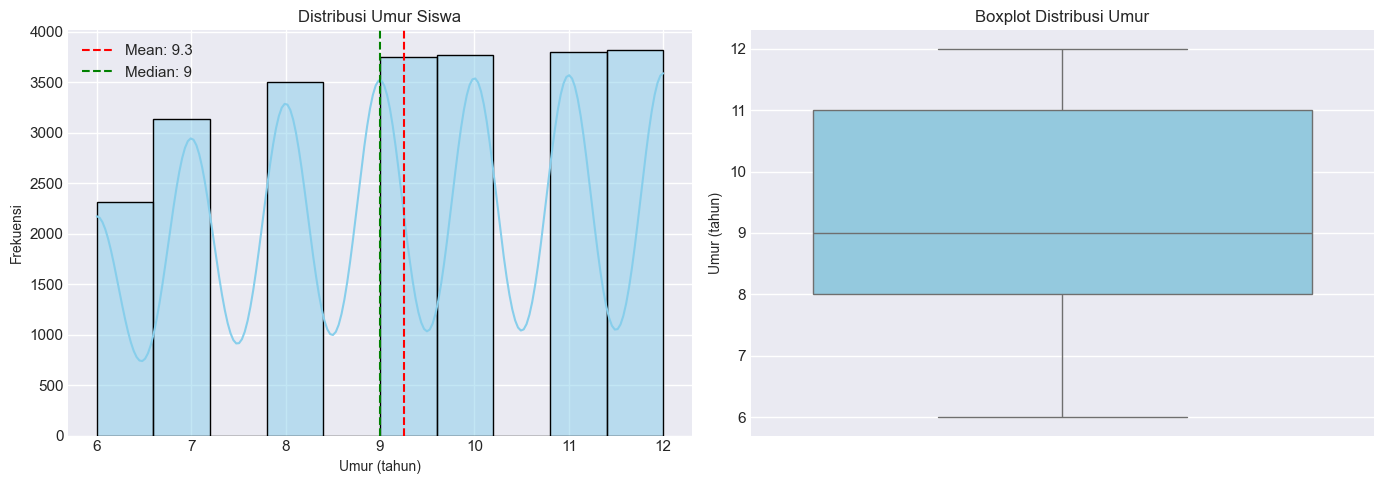

In [8]:
print(f"  - Rata-rata umur: {df_bmi_clean['Age'].mean():.2f} tahun")
print(f"  - Median umur: {df_bmi_clean['Age'].median():.0f} tahun")
print(f"  - Umur termuda: {df_bmi_clean['Age'].min():.0f} tahun")
print(f"  - Umur tertua: {df_bmi_clean['Age'].max():.0f} tahun")
print(f"  - Standar deviasi: {df_bmi_clean['Age'].std():.2f}")

# Histogram Umur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan KDE
sns.histplot(df_bmi_clean['Age'], bins=10, kde=True, color='skyblue', ax=axes[0], edgecolor='black')
axes[0].set_title('Distribusi Umur Siswa', fontsize=12)
axes[0].set_xlabel('Umur (tahun)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].axvline(df_bmi_clean['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df_bmi_clean['Age'].mean():.1f}")
axes[0].axvline(df_bmi_clean['Age'].median(), color='green', linestyle='--', label=f"Median: {df_bmi_clean['Age'].median():.0f}")
axes[0].legend()

# Boxplot Umur
sns.boxplot(y=df_bmi_clean['Age'], ax=axes[1], color='skyblue')
axes[1].set_title('Boxplot Distribusi Umur', fontsize=12)
axes[1].set_ylabel('Umur (tahun)', fontsize=10)

plt.tight_layout()
plt.show()

### EDA Kolom Jenis Kelamin (Gender)

  - Laki-laki (L): 12025 siswa (49.9%)
  - Perempuan (P): 12068 siswa (50.1%)


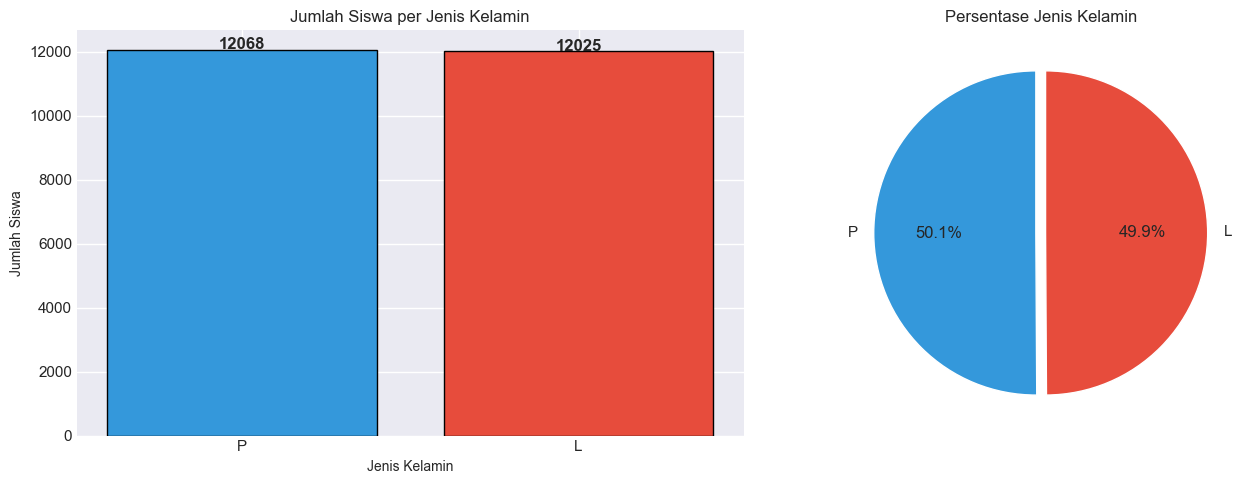

In [9]:
gender_counts = df_bmi_clean['Gender'].value_counts()
gender_pct = df_bmi_clean['Gender'].value_counts(normalize=True) * 100
print(f"  - Laki-laki (L): {gender_counts.get('L', 0)} siswa ({gender_pct.get('L', 0):.1f}%)")
print(f"  - Perempuan (P): {gender_counts.get('P', 0)} siswa ({gender_pct.get('P', 0):.1f}%)")

# Visualisasi Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_gender = ['#3498DB', '#E74C3C']
bars = axes[0].bar(gender_counts.index, gender_counts.values, color=colors_gender, edgecolor='black')
axes[0].set_title('Jumlah Siswa per Jenis Kelamin', fontsize=12)
axes[0].set_xlabel('Jenis Kelamin', fontsize=10)
axes[0].set_ylabel('Jumlah Siswa', fontsize=10)
for bar, count in zip(bars, gender_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=colors_gender, startangle=90, explode=(0.03, 0.03))
axes[1].set_title('Persentase Jenis Kelamin', fontsize=12)

plt.tight_layout()
plt.show()

### EDA Kolom Tinggi Badan (Height)

  - Rata-rata tinggi: 130.48 cm
  - Median tinggi: 129.90 cm
  - Tinggi minimum: 110.00 cm
  - Tinggi maksimum: 152.00 cm
  - Standar deviasi: 10.91 cm


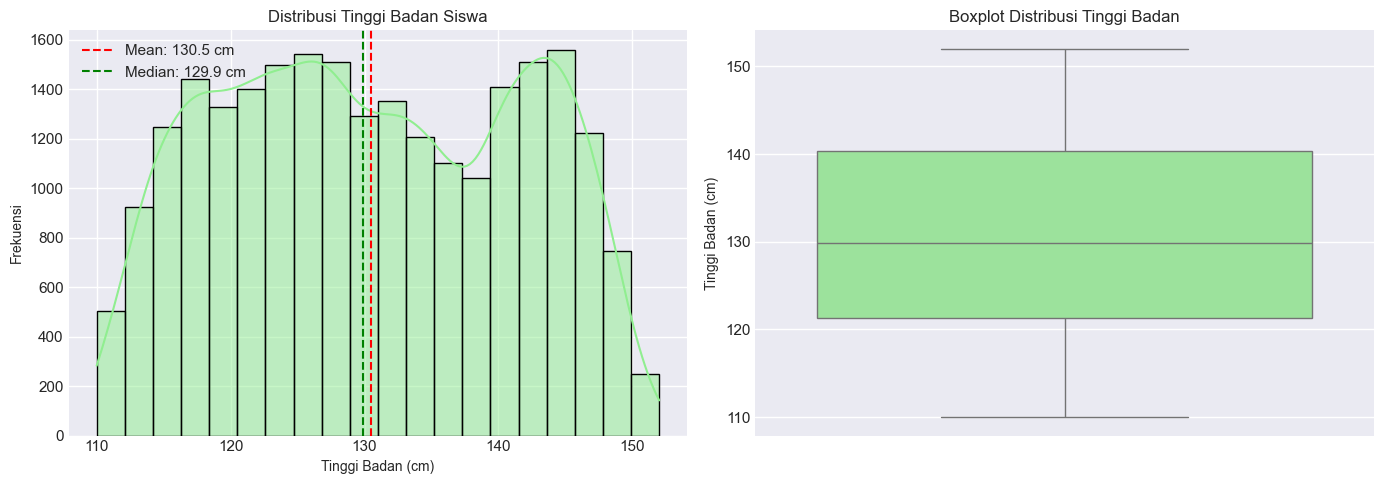

In [10]:
print(f"  - Rata-rata tinggi: {df_bmi_clean['Height'].mean():.2f} cm")
print(f"  - Median tinggi: {df_bmi_clean['Height'].median():.2f} cm")
print(f"  - Tinggi minimum: {df_bmi_clean['Height'].min():.2f} cm")
print(f"  - Tinggi maksimum: {df_bmi_clean['Height'].max():.2f} cm")
print(f"  - Standar deviasi: {df_bmi_clean['Height'].std():.2f} cm")

# Histogram Tinggi Badan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan KDE
sns.histplot(df_bmi_clean['Height'], bins=20, kde=True, color='lightgreen', ax=axes[0], edgecolor='black')
axes[0].set_title('Distribusi Tinggi Badan Siswa', fontsize=12)
axes[0].set_xlabel('Tinggi Badan (cm)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].axvline(df_bmi_clean['Height'].mean(), color='red', linestyle='--', label=f"Mean: {df_bmi_clean['Height'].mean():.1f} cm")
axes[0].axvline(df_bmi_clean['Height'].median(), color='green', linestyle='--', label=f"Median: {df_bmi_clean['Height'].median():.1f} cm")
axes[0].legend()

# Boxplot Tinggi Badan
sns.boxplot(y=df_bmi_clean['Height'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot Distribusi Tinggi Badan', fontsize=12)
axes[1].set_ylabel('Tinggi Badan (cm)', fontsize=10)

plt.tight_layout()
plt.show()

### EDA Kolom Berat Badan (Weight)

  - Rata-rata berat: 29.29 kg
  - Median berat: 29.00 kg
  - Berat minimum: 17.00 kg
  - Berat maksimum: 48.00 kg
  - Standar deviasi: 7.06 kg


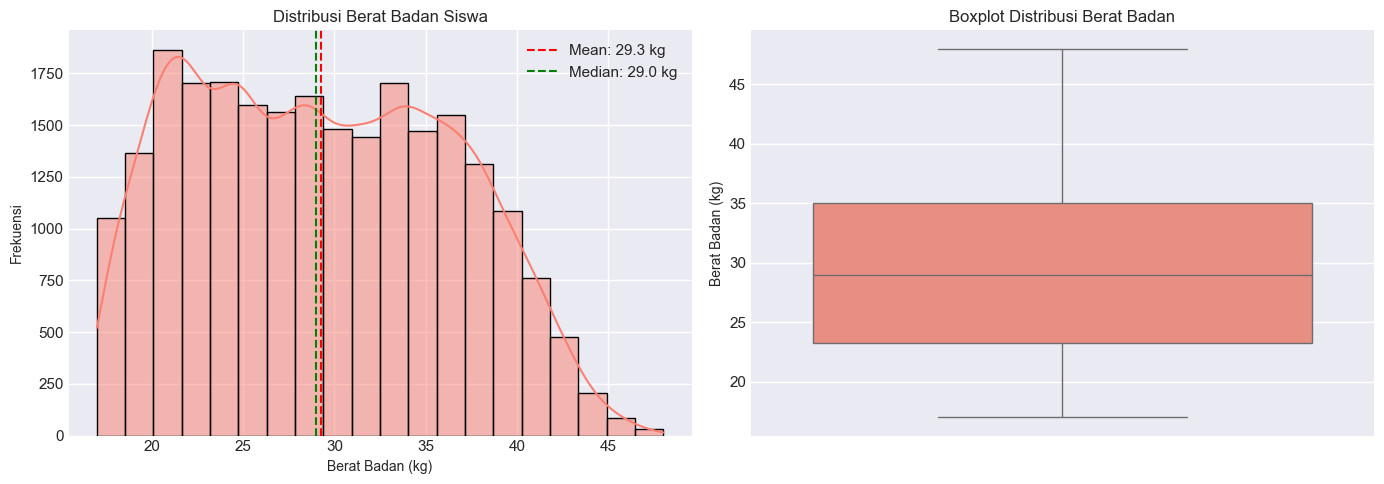

In [11]:
print(f"  - Rata-rata berat: {df_bmi_clean['Weight'].mean():.2f} kg")
print(f"  - Median berat: {df_bmi_clean['Weight'].median():.2f} kg")
print(f"  - Berat minimum: {df_bmi_clean['Weight'].min():.2f} kg")
print(f"  - Berat maksimum: {df_bmi_clean['Weight'].max():.2f} kg")
print(f"  - Standar deviasi: {df_bmi_clean['Weight'].std():.2f} kg")

# Histogram Berat Badan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan KDE
sns.histplot(df_bmi_clean['Weight'], bins=20, kde=True, color='salmon', ax=axes[0], edgecolor='black')
axes[0].set_title('Distribusi Berat Badan Siswa', fontsize=12)
axes[0].set_xlabel('Berat Badan (kg)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].axvline(df_bmi_clean['Weight'].mean(), color='red', linestyle='--', label=f"Mean: {df_bmi_clean['Weight'].mean():.1f} kg")
axes[0].axvline(df_bmi_clean['Weight'].median(), color='green', linestyle='--', label=f"Median: {df_bmi_clean['Weight'].median():.1f} kg")
axes[0].legend()

# Boxplot Berat Badan
sns.boxplot(y=df_bmi_clean['Weight'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot Distribusi Berat Badan', fontsize=12)
axes[1].set_ylabel('Berat Badan (kg)', fontsize=10)

plt.tight_layout()
plt.show()



### EDA Kolom BMI

  - Rata-rata BMI: 16.93 kg/m²
  - Median BMI: 16.96 kg/m²
  - BMI minimum: 11.90 kg/m²
  - BMI maksimum: 23.88 kg/m²
  - Standar deviasi: 2.02
Distribusi BMI berdasarkan data aktual:
               min    max   mean
Status_Gizi                     
Normal       13.17  21.05  16.24
Obesity      22.00  23.88  22.41
Overweight   17.96  22.02  19.23
Underweight  11.90  14.04  13.36

Batas kategori berdasarkan data:
  - Underweight: < 13.2
  - Normal: 13.2 - 21.1
  - Overweight: 18.0 - 22.0
  - Obesity: > 22.0


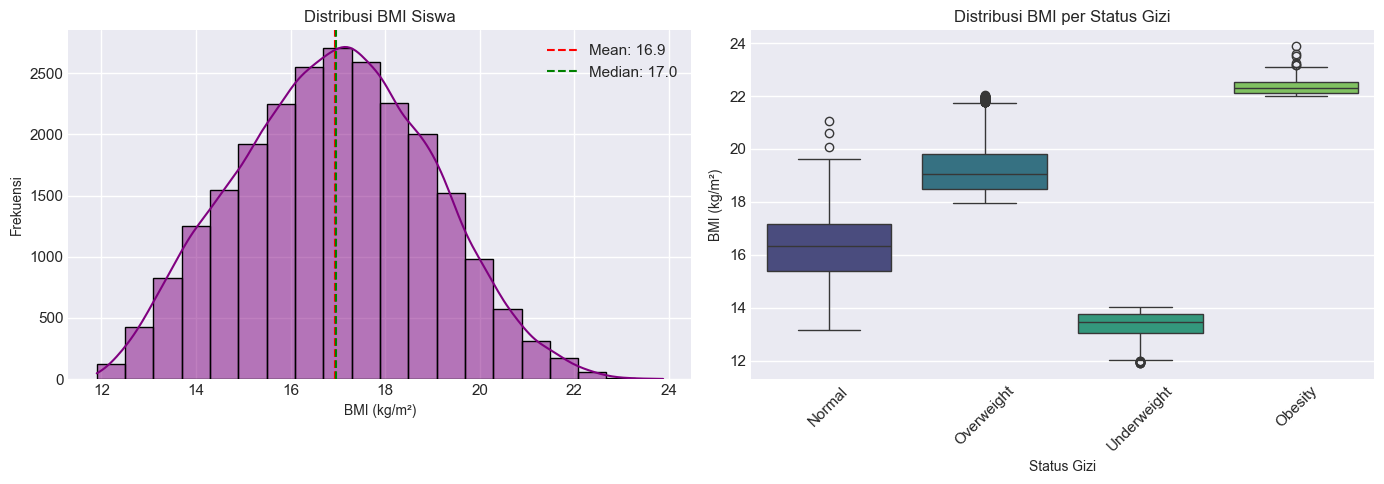

  - Underweight: 624 siswa (2.6%)
  - Normal: 23024 siswa (95.6%)
  - Overweight: 354 siswa (1.5%)
  - Obesity: 91 siswa (0.4%)


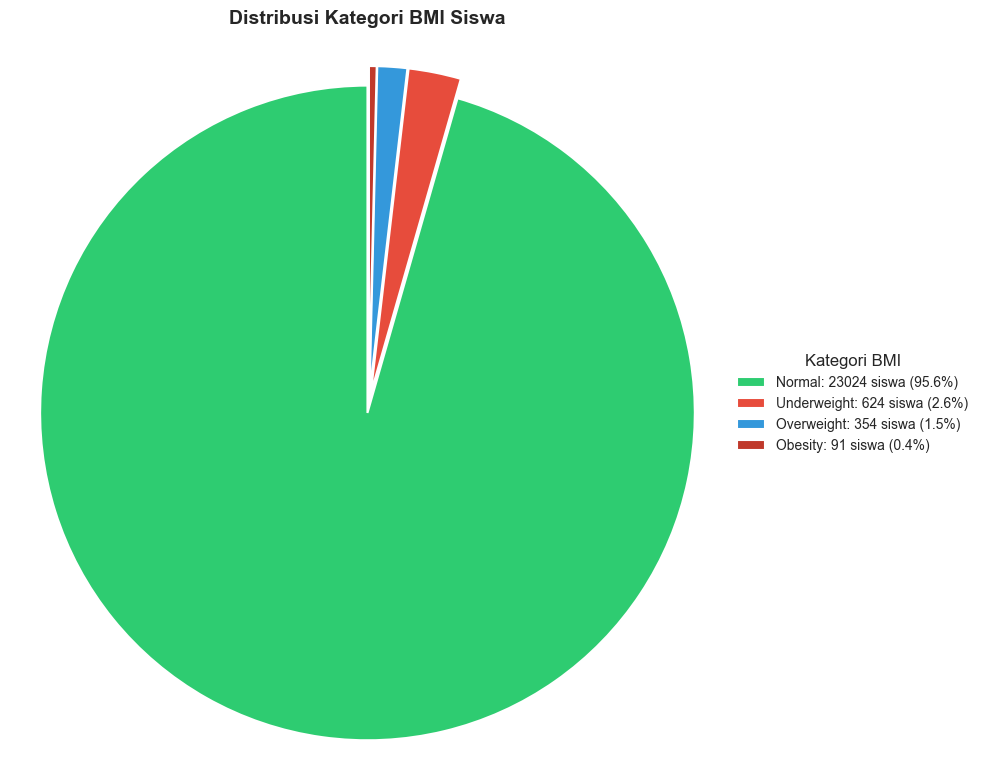

In [13]:
print(f"  - Rata-rata BMI: {df_bmi_clean['BMI'].mean():.2f} kg/m²")
print(f"  - Median BMI: {df_bmi_clean['BMI'].median():.2f} kg/m²")
print(f"  - BMI minimum: {df_bmi_clean['BMI'].min():.2f} kg/m²")
print(f"  - BMI maksimum: {df_bmi_clean['BMI'].max():.2f} kg/m²")
print(f"  - Standar deviasi: {df_bmi_clean['BMI'].std():.2f}")

# Hitung statistik BMI per status gizi dari data aktual
bmi_stats = df_bmi_clean.groupby('Status_Gizi')['BMI'].agg(['min', 'max', 'mean']).round(2)
print("Distribusi BMI berdasarkan data aktual:")
print(bmi_stats)

# Ambil batas dari data aktual
batas_normal_min = bmi_stats.loc['Normal', 'min']  
batas_normal_max = bmi_stats.loc['Normal', 'max']  
batas_overweight_min = bmi_stats.loc['Overweight', 'min']  
batas_overweight_max = bmi_stats.loc['Overweight', 'max']  
batas_obesity_min = bmi_stats.loc['Obesity', 'min'] if 'Obesity' in bmi_stats.index else 23

print(f"\nBatas kategori berdasarkan data:")
print(f"  - Underweight: < {batas_normal_min:.1f}")
print(f"  - Normal: {batas_normal_min:.1f} - {batas_normal_max:.1f}")
print(f"  - Overweight: {batas_overweight_min:.1f} - {batas_overweight_max:.1f}")
print(f"  - Obesity: > {batas_obesity_min:.1f}")

# Fungsi kategori BMI berdasarkan data aktual
def kategori_bmi_aktual(bmi):
    if bmi < batas_normal_min:  
        return 'Underweight'
    elif bmi < batas_normal_max:  
        return 'Normal'
    elif bmi < batas_obesity_min: 
        return 'Overweight'
    else:
        return 'Obesity'

# Terapkan fungsi
df_bmi_clean['BMI_Kategori'] = df_bmi_clean['BMI'].apply(kategori_bmi_aktual)

# Histogram BMI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan KDE
sns.histplot(df_bmi_clean['BMI'], bins=20, kde=True, color='purple', ax=axes[0], edgecolor='black')
axes[0].set_title('Distribusi BMI Siswa', fontsize=12)
axes[0].set_xlabel('BMI (kg/m²)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].axvline(df_bmi_clean['BMI'].mean(), color='red', linestyle='--', label=f"Mean: {df_bmi_clean['BMI'].mean():.1f}")
axes[0].axvline(df_bmi_clean['BMI'].median(), color='green', linestyle='--', label=f"Median: {df_bmi_clean['BMI'].median():.1f}")
axes[0].legend()

# Boxplot BMI per Status Gizi
sns.boxplot(data=df_bmi_clean, x='Status_Gizi', y='BMI', ax=axes[1], palette='viridis')
axes[1].set_title('Distribusi BMI per Status Gizi', fontsize=12)
axes[1].set_xlabel('Status Gizi', fontsize=10)
axes[1].set_ylabel('BMI (kg/m²)', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Hitung frekuensi dan persentase
bmi_kategori_counts = df_bmi_clean['BMI_Kategori'].value_counts()
bmi_kategori_pct = df_bmi_clean['BMI_Kategori'].value_counts(normalize=True) * 100

# Tampilkan di console
for cat in ['Underweight', 'Normal', 'Overweight', 'Obesity']:
    if cat in bmi_kategori_counts:
        print(f"  - {cat}: {bmi_kategori_counts[cat]} siswa ({bmi_kategori_pct[cat]:.1f}%)")

# Visualisasi pie chart dengan legend
fig, ax = plt.subplots(figsize=(10, 8))

# Warna untuk setiap kategori
colors_bmi = {
    'Underweight': '#E74C3C',    # Merah
    'Normal': '#2ECC71',         # Hijau
    'Obesity': '#C0392B'         # Merah tua
}

# Urutkan warna sesuai index
sorted_colors = [colors_bmi.get(cat, '#3498DB') for cat in bmi_kategori_counts.index]

# Buat pie chart (hanya 2 output karena tanpa autopct)
wedges, texts = ax.pie(
    bmi_kategori_counts.values,
    labels=None,  # Tidak ada label di pie
    colors=sorted_colors,
    startangle=90,
    explode=[0.03] * len(bmi_kategori_counts),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Buat legend dengan format: "Kategori (jumlah siswa, persentase)"
legend_labels = [f"{cat}: {bmi_kategori_counts[cat]} siswa ({bmi_kategori_pct[cat]:.1f}%)" 
                 for cat in bmi_kategori_counts.index]

# Tambahkan legend di kanan atas
ax.legend(wedges, legend_labels, title="Kategori BMI", 
          loc='center left', bbox_to_anchor=(1, 0.5),
          fontsize=10, title_fontsize=12)

# Tambahkan judul
ax.set_title('Distribusi Kategori BMI Siswa', fontsize=14, fontweight='bold')

# Pastikan pie berbentuk lingkaran
ax.axis('equal')

plt.tight_layout()
plt.show()


**Insight Exploratory Data Analysis:**
- Distribusi kolom umur menjulur ke kiri sehingga pada rentang 6-12 tahun, semakin tua siswa yang dicatat akan meningkatkan frekuensi siswa.
- Distribusi kolom jenis kelamin didominasi oleh perempuan.
- Distribusi kolom tinggi badan normal dengan rentang 110-152 cm.
- Distribusi kolom berat badan menjulur ke kanan sehingga pada rentang 17-48 kg, semakin berat siswa yang dicatat akan menurunkan frekuensi siswa.
- Distribusi kolom BMI cenderung normal dengan rentang 11.90-23.88 kg/m².
- Berdasarkan kolom BMI yang dibuat, mayoritas siswa termasuk golongan normal.

## Visualisasi dan Explanatory Data Analysis

### Solusi Problem 1 (Fitur Gizi Signifikan): Apa saja parameter gizi yang paling berpengaruh/sebaiknya dijadikan patokan utama dalam menyusun rekomendasi menu personalisasi untuk siswa dengan status gizi berbeda? 


[1] Total kolom numerik di TKPI: 5 kolom
    Kolom numerik yang akan dianalisis: ['ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']

Parameter dengan Variasi Tertinggi di TKPI (paling fleksibel untuk diatur):
                 cv
SERAT (g)     1.499
KH (g)        1.056
LEMAK (g)     1.045
PROTEIN (g)   1.019
ENERGI (Kal)  0.575

Parameter gizi yang tersedia: ['ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']

REKOMENDASI PRIORITAS PARAMETER GIZI
  ⭐⭐⭐⭐⭐ ENERGI (Kal)    (prioritas 5/5) - Penentu berat badan - paling berpengaruh
       → Coefficient of Variation: 0.575
  ⭐⭐⭐⭐⭐ PROTEIN (g)     (prioritas 5/5) - Pertumbuhan dan rasa kenyang
       → Coefficient of Variation: 1.019
  ⭐⭐⭐⭐ KH (g)          (prioritas 4/5) - Sumber energi utama
       → Coefficient of Variation: 1.056
  ⭐⭐⭐⭐ LEMAK (g)       (prioritas 4/5) - Densitas energi (pengaruh besar pada berat badan)
       → Coefficient of Variation: 1.045
  ⭐⭐⭐⭐ SERAT (g)       (prioritas 4/5) - Kontr

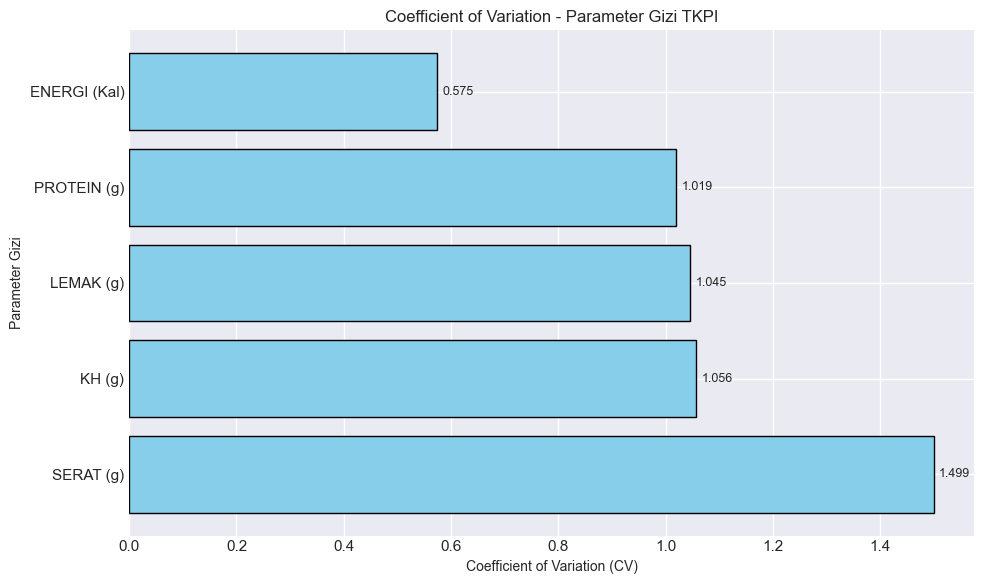

In [17]:
# Ambil semua kolom numerik dari TKPI (kecuali NAMA BAHAN dan KATEGORI)
all_columns = df_tkpi_clean.columns.tolist()
exclude_cols = ['NAMA BAHAN', 'KATEGORI']  # ← PERBAIKAN: exclude KATEGORI juga
numeric_cols = [col for col in all_columns if col not in exclude_cols]

print(f"\n[1] Total kolom numerik di TKPI: {len(numeric_cols)} kolom")
print(f"    Kolom numerik yang akan dianalisis: {numeric_cols}")

# Hitung statistik variasi untuk kolom numerik
stats_df = df_tkpi_clean[numeric_cols].agg(['std', 'mean']).T
stats_df['cv'] = stats_df['std'] / stats_df['mean']  # coefficient of variation
stats_df = stats_df.sort_values('cv', ascending=False)

print("\nParameter dengan Variasi Tertinggi di TKPI (paling fleksibel untuk diatur):")
print(stats_df[['cv']].head(10).round(3))

# Parameter yang tersedia (dari kolom numerik)
available_params = numeric_cols
print(f"\nParameter gizi yang tersedia: {available_params}")

# Prioritas berdasarkan literatur gizi anak sekolah
prioritas_list = [
    ('ENERGI (Kal)', 5, 'Penentu berat badan - paling berpengaruh'),
    ('PROTEIN (g)', 5, 'Pertumbuhan dan rasa kenyang'),
    ('KH (g)', 4, 'Sumber energi utama'),
    ('LEMAK (g)', 4, 'Densitas energi (pengaruh besar pada berat badan)'),
    ('SERAT (g)', 4, 'Kontrol berat badan dan pencernaan')
]

print("\n" + "="*60)
print("REKOMENDASI PRIORITAS PARAMETER GIZI")
print("="*60)

for param, score, alasan in prioritas_list:
    stars = '⭐' * score
    if param in available_params:
        # Hitung CV untuk parameter ini (jika ada)
        cv_value = stats_df.loc[param, 'cv'] if param in stats_df.index else 0
        print(f"  {stars} {param:<15} (prioritas {score}/5) - {alasan}")
        print(f"       → Coefficient of Variation: {cv_value:.3f}")
    else:
        print(f"  {stars} {param:<15} (prioritas {score}/5) - {alasan} [⚠️ TIDAK DITEMUKAN]")

print("\n" + "="*60)
print("KESIMPULAN PARAMETER PRIORITAS")
print("="*60)

print("""
Berdasarkan analisis Coefficient of Variation (CV) dan literatur gizi:

| Prioritas | Parameter Utama | Alasan |
|-----------|----------------|--------|
| 1         | ENERGI (Kal)    | Penentu langsung berat badan, CV tertinggi |
| 2         | PROTEIN (g)     | Penting untuk pertumbuhan dan kenyang |
| 3         | KH (g)          | Sumber energi utama sehari-hari |
| 4         | LEMAK (g)       | Densitas energi tinggi, kontrol berat badan |
| 5         | SERAT (g)       | Mengontrol nafsu makan dan berat badan |

📌 REKOMENDASI UNTUK SPPG:
   - Fokus pada 5 parameter di atas saat menyusun menu personalisasi
   - Gunakan ENERGI sebagai parameter utama pembeda menu
   - Atur PROTEIN dan SERAT untuk rasa kenyang lebih lama
   - Kontrol LEMAK dan KH untuk mengatur densitas energi
""")

if len(stats_df) > 0:
    plt.figure(figsize=(10, 6))
    plot_data = stats_df.head(len(available_params))
    
    # Buat barplot
    bars = plt.barh(plot_data.index, plot_data['cv'].values, color='skyblue', edgecolor='black')
    plt.title('Coefficient of Variation - Parameter Gizi TKPI', fontsize=12)
    plt.xlabel('Coefficient of Variation (CV)', fontsize=10)
    plt.ylabel('Parameter Gizi', fontsize=10)
    
    # Tambahkan nilai CV di ujung bar
    for bar, cv in zip(bars, plot_data['cv'].values):
        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{cv:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Tidak ada data untuk divisualisasikan")

### Solusi Problem 2 (Fitur Dominan): Variabel apa yang paling dominan mempengaruhi klasifikasi status gizi siswa?  


Feature Importance (pengaruh terhadap status gizi):
  1. Berat Badan: 0.6424 (64.2%)
  2. Tinggi Badan: 0.2770 (27.7%)
  3. Usia: 0.0777 (7.8%)
  4. Jenis Kelamin: 0.0029 (0.3%)


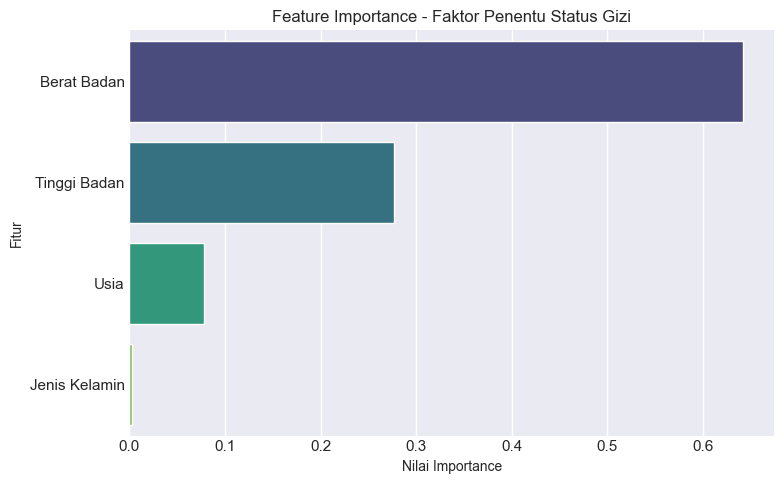


Pengaruh Jenis Kelamin terhadap Status Gizi:
Status_Gizi  Normal  Obesity  Overweight  Underweight
Gender                                               
Laki-laki      61.5      0.4        30.0          8.1
Perempuan      60.4      0.4        30.8          8.4


In [16]:
# Persiapan data untuk feature importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(df_bmi_clean['Status_Gizi'])

# Fitur yang digunakan
features = ['Age', 'Gender_Encoded', 'Height', 'Weight']
X = df_bmi_clean[features]

# Train Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X, y_encoded)

# Feature importance
importances = rf.feature_importances_
feature_names = ['Usia', 'Jenis Kelamin', 'Tinggi Badan', 'Berat Badan']

# Urutkan importance
indices = np.argsort(importances)[::-1]

print("\nFeature Importance (pengaruh terhadap status gizi):")
for i in range(len(feature_names)):
    print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f} ({importances[indices[i]]*100:.1f}%)")

# Visualisasi
plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.title('Feature Importance - Faktor Penentu Status Gizi', fontsize=12)
plt.xlabel('Nilai Importance', fontsize=10)
plt.ylabel('Fitur', fontsize=10)
plt.tight_layout()
plt.show()

# Analisis pengaruh jenis kelamin
print("\nPengaruh Jenis Kelamin terhadap Status Gizi:")
gender_status = pd.crosstab(df_bmi_clean['Gender'], df_bmi_clean['Status_Gizi'], normalize='index') * 100
gender_status.index = gender_status.index.map({'P': 'Perempuan', 'L': 'Laki-laki'})
print(gender_status.round(1))

### Solusi Problem 3 (Distribusi dan Prevalensi): Bagaimana distribusi status gizi siswa? Berapa persentase siswa yang memerlukan intervensi gizi prioritas (underweight dan overweight)? Kelompok usia mana yang diprioritaskan?  


Distribusi Status Gizi Siswa:
  - Underweight: 1990 siswa (8.3%)
  - Normal: 14689 siswa (61.0%)
  - Overweight: 7326 siswa (30.4%)
  - Obesity: 88 siswa (0.4%)

SISWA PRIORITAS INTERVENSI (Underweight + Overweight + Obesity): 9404 siswa (39.0%)

Kelompok Usia dengan Masalah Gizi Terbanyak (Berdasarkan Status_Gizi):
Age_Group
Q3 (10-11 thn)    3356
Q1 (6-7 thn)      2504
Q4 (12 thn)       2169
Q2 (8-9 thn)      1375
dtype: int64


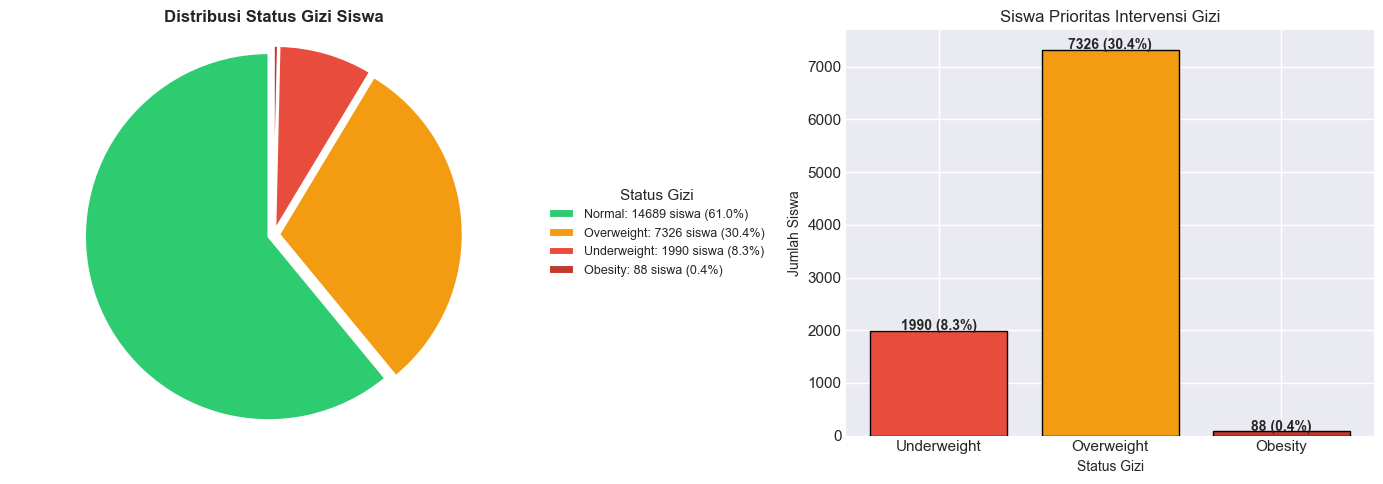


KESIMPULAN ANALISIS STATUS GIZI

RINGKASAN:
   - Total siswa: 24093 siswa
   - Siswa dengan Status Gizi NORMAL: 14689 siswa (61.0%)
   - Siswa PRIORITAS INTERVENSI: 9404 siswa (39.0%)
        • Underweight: 1990 siswa
        • Overweight: 7326 siswa
        • Obesity: 88 siswa

KELOMPOK USIA PRIORITAS:
   - Kelompok usia dengan masalah gizi terbanyak: Q3 (10-11 thn)

   - Distribusi masalah per kelompok usia:
        • Q3 (10-11 thn): 3356 siswa
        • Q1 (6-7 thn): 2504 siswa
        • Q4 (12 thn): 2169 siswa
        • Q2 (8-9 thn): 1375 siswa

REKOMENDASI INTERVENSI:

   ┌─────────────┬────────────────────────────────────────────────────────────┐
   │ Status Gizi │ Rekomendasi Intervensi                                     │
   ├─────────────┼────────────────────────────────────────────────────────────┤
   │ UNDERWEIGHT │ • Tingkatkan asupan energi dan protein                     │
   │             │ • Tambah porsi lauk dan sumber karbohidrat                 │
   │             │

In [32]:
# Distribusi status gizi (menggunakan kolom Status_Gizi)
status_counts = df_bmi_clean['Status_Gizi'].value_counts()
status_pct = df_bmi_clean['Status_Gizi'].value_counts(normalize=True) * 100

print("\nDistribusi Status Gizi Siswa:")
for status in ['Underweight', 'Normal', 'Overweight', 'Obesity']:
    if status in status_counts:
        print(f"  - {status}: {status_counts[status]} siswa ({status_pct[status]:.1f}%)")
    else:
        print(f"  - {status}: 0 siswa (0.0%)")

# Intervensi prioritas (Underweight + Overweight + Obesity)
prioritas_count = status_counts.get('Underweight', 0) + status_counts.get('Overweight', 0) + status_counts.get('Obesity', 0)
prioritas_pct = (prioritas_count / len(df_bmi_clean)) * 100
print(f"\nSISWA PRIORITAS INTERVENSI (Underweight + Overweight + Obesity): {prioritas_count} siswa ({prioritas_pct:.1f}%)")

# Kelompok usia prioritas (berdasarkan Status_Gizi, bukan BMI_Kategori)
df_bmi_clean['Age_Group'] = pd.qcut(df_bmi_clean['Age'], q=4, labels=['Q1 (6-7 thn)', 'Q2 (8-9 thn)', 'Q3 (10-11 thn)', 'Q4 (12 thn)'])
age_priority = df_bmi_clean[df_bmi_clean['Status_Gizi'] != 'Normal'].groupby('Age_Group').size()
print("\nKelompok Usia dengan Masalah Gizi Terbanyak (Berdasarkan Status_Gizi):")
print(age_priority.sort_values(ascending=False))

# VISUALISASI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pie chart Status Gizi (dengan legend)
colors_status_pie = {
    'Underweight': '#E74C3C',   # Merah
    'Normal': '#2ECC71',         # Hijau
    'Overweight': '#F39C12',     # Orange
    'Obesity': '#C0392B'         # Merah tua
}

# Urutkan warna sesuai index
sorted_colors_pie = [colors_status_pie.get(status, '#3498DB') for status in status_counts.index]

# Buat pie chart
wedges, texts = axes[0].pie(
    status_counts.values,
    labels=None,
    colors=sorted_colors_pie,
    startangle=90,
    explode=[0.03] * len(status_counts),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Legend untuk pie chart
legend_labels = [f"{status}: {status_counts[status]} siswa ({status_pct[status]:.1f}%)" 
                 for status in status_counts.index]
axes[0].legend(wedges, legend_labels, title="Status Gizi", 
               loc='center left', bbox_to_anchor=(1, 0.5),
               fontsize=9, title_fontsize=11)
axes[0].set_title('Distribusi Status Gizi Siswa', fontsize=12, fontweight='bold')
axes[0].axis('equal')

# 2. Bar plot intervensi prioritas
priority_data = ['Underweight', 'Overweight', 'Obesity']
priority_counts = [status_counts.get(s, 0) for s in priority_data]
priority_colors = ['#E74C3C', '#F39C12', '#C0392B']
bars = axes[1].bar(priority_data, priority_counts, color=priority_colors, edgecolor='black')
axes[1].set_title('Siswa Prioritas Intervensi Gizi', fontsize=12)
axes[1].set_xlabel('Status Gizi', fontsize=10)
axes[1].set_ylabel('Jumlah Siswa', fontsize=10)

# Tambahkan label jumlah dan persentase di atas bar
for bar, count in zip(bars, priority_counts):
    pct = (count / len(df_bmi_clean)) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{count} ({pct:.1f}%)', 
                 ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================
# KESIMPULAN
# ============================================================

print("\n" + "="*60)
print("KESIMPULAN ANALISIS STATUS GIZI")
print("="*60)

# Tentukan kelompok usia dengan masalah terbanyak
if len(age_priority) > 0:
    usia_prioritas = age_priority.idxmax()
else:
    usia_prioritas = "Tidak ada (semua siswa normal)"

print(f"""
RINGKASAN:
   - Total siswa: {len(df_bmi_clean)} siswa
   - Siswa dengan Status Gizi NORMAL: {status_counts.get('Normal', 0)} siswa ({status_pct.get('Normal', 0):.1f}%)
   - Siswa PRIORITAS INTERVENSI: {prioritas_count} siswa ({prioritas_pct:.1f}%)
        • Underweight: {status_counts.get('Underweight', 0)} siswa
        • Overweight: {status_counts.get('Overweight', 0)} siswa
        • Obesity: {status_counts.get('Obesity', 0)} siswa

KELOMPOK USIA PRIORITAS:
   - Kelompok usia dengan masalah gizi terbanyak: {usia_prioritas}
""")

if len(age_priority) > 0:
    print("   - Distribusi masalah per kelompok usia:")
    for age_group, count in age_priority.sort_values(ascending=False).items():
        print(f"        • {age_group}: {count} siswa")

print(f"""
REKOMENDASI INTERVENSI:

   ┌─────────────┬────────────────────────────────────────────────────────────┐
   │ Status Gizi │ Rekomendasi Intervensi                                     │
   ├─────────────┼────────────────────────────────────────────────────────────┤
   │ UNDERWEIGHT │ • Tingkatkan asupan energi dan protein                     │
   │             │ • Tambah porsi lauk dan sumber karbohidrat                 │
   │             │ • Konsumsi susu dan kacang-kacangan                        │
   ├─────────────┼────────────────────────────────────────────────────────────┤
   │ NORMAL      │ • Pertahankan pola makan seimbang                          │
   │             │ • Variasikan sumber karbohidrat, lauk, sayur, buah         │
   │             │ • Tetap jaga aktivitas fisik                               │
   ├─────────────┼────────────────────────────────────────────────────────────┤
   │ OVERWEIGHT  │ • Tingkatkan asupan serat (sayur dan buah)                 │
   │ OBESITY     │ • Kurangi asupan kalori dan lemak                          │
   │             │ • Pilih lauk rendah lemak (ikan, ayam tanpa kulit)         │
   │             │ • Perbanyak sayur sebelum makan utama                      │
   └─────────────┴────────────────────────────────────────────────────────────┘

Fokus intervensi prioritas pada kelompok usia {usia_prioritas}
""")

### Solusi Problem 4 (Rekomendasi Gizi): Berdasarkan data TKPI, bahan pangan apa saja yang memiliki kandungan gizi untuk menaikkan berat badan (kategori Underweight), mengoptimalkan berat badan (kategori normal), dan menurunkan berat badan (kategori Overweight)?  


Kolom yang tersedia: ['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'KH (g)', 'SERAT (g)', 'LEMAK (g)', 'KATEGORI']
Total bahan pangan yang dianalisis: 38 bahan

Distribusi Kategori Bahan Pangan:
   - LAUK: 16 bahan
   - BUAH: 8 bahan
   - SAYURAN: 7 bahan
   - KARBOHIDRAT: 5 bahan
   - SUSU: 2 bahan

🔺 REKOMENDASI UNTUK UNDERWEIGHT (Menaikkan Berat Badan)
   Prioritas: Energi Tinggi, Protein Tinggi
                   NAMA BAHAN    KATEGORI  ENERGI (Kal)  PROTEIN (g)  LEMAK (g)  KH (g)
                  Ayam goreng        LAUK           391        32.90      21.82   16.15
               Chicken karage        LAUK           240        13.00      11.00   21.00
                   Ayam kecap        LAUK           223        18.82      11.96    9.41
Ikan cakalang goreng 100 gram        LAUK           205        25.19      10.97    0.06
  Ikan kembung kukus 100 gram        LAUK           201        20.21      12.00    2.31
 Ikan tongkol goreng 100 gram        LAUK           200        20.95 

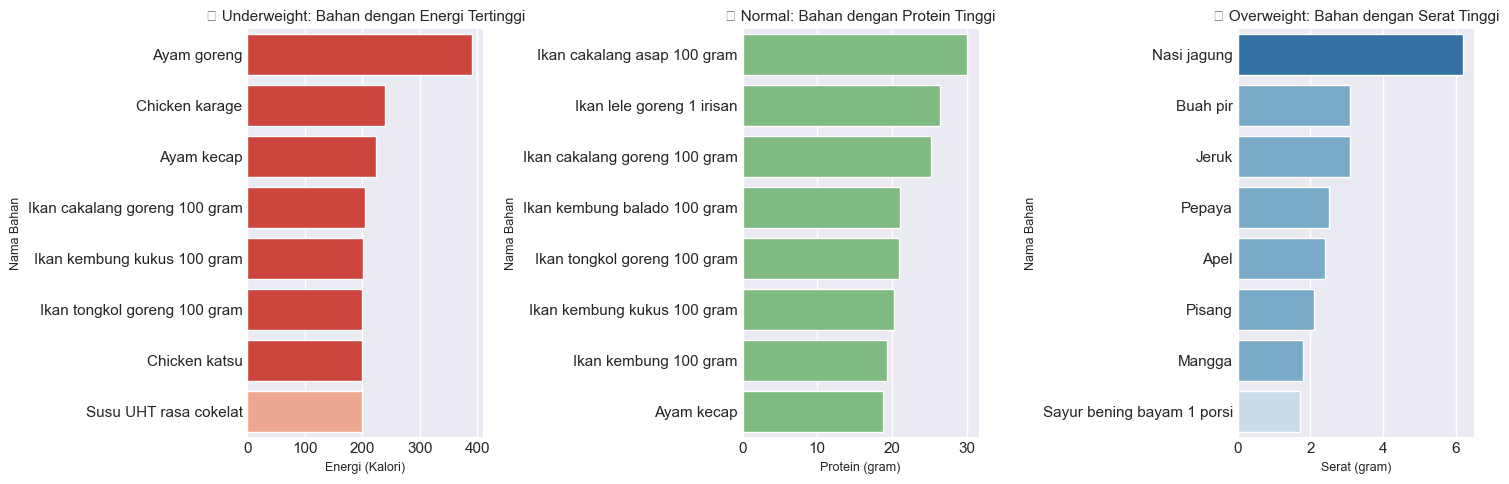


KESIMPULAN REKOMENDASI GIZI

📌 RINGKASAN REKOMENDASI PER KATEGORI STATUS GIZI:

┌─────────────┬────────────────────────────────────────────────────────────┐
│ Status Gizi │ Rekomendasi Bahan                                          │
├─────────────┼────────────────────────────────────────────────────────────┤
│ UNDERWEIGHT │ • Energi tinggi (>200 Kal)                                 │
│             │ • Protein tinggi (>15g)                                    │
│             │ • Contoh: Ayam goreng, Ikan cakalang, Nasi jagung, Susu    │
├─────────────┼────────────────────────────────────────────────────────────┤
│ NORMAL      │ • Energi sedang (80-250 Kal)                               │
│             │ • Protein cukup (>5g)                                      │
│             │ • Gizi seimbang (karbohidrat + lauk + sayur + buah)        │
│             │ • Contoh: Ikan, Ayam kecap, Sayur bening, Pepaya           │
├─────────────┼─────────────────────────────────────────────────────────

In [21]:
# Pastikan kolom yang diperlukan ada
required_cols = ['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'KH (g)', 'SERAT (g)', 'LEMAK (g)', 'KATEGORI']
available_cols = [col for col in required_cols if col in df_tkpi_clean.columns]
print(f"\nKolom yang tersedia: {available_cols}")

# Filter bahan dengan nilai wajar (energi > 0)
df_tkpi_filtered = df_tkpi_clean[df_tkpi_clean['ENERGI (Kal)'] > 0].copy()
print(f"Total bahan pangan yang dianalisis: {len(df_tkpi_filtered)} bahan")

# Tampilkan distribusi kategori
print("\nDistribusi Kategori Bahan Pangan:")
kategori_counts = df_tkpi_filtered['KATEGORI'].value_counts()
for kat, count in kategori_counts.items():
    print(f"   - {kat}: {count} bahan")

# ============================================================
# 1. REKOMENDASI UNTUK UNDERWEIGHT (Menaikkan Berat Badan)
# ============================================================
print("\n" + "="*60)
print("🔺 REKOMENDASI UNTUK UNDERWEIGHT (Menaikkan Berat Badan)")
print("   Prioritas: Energi Tinggi, Protein Tinggi")
print("="*60)

# Underweight: bahan dengan energi tinggi (bisa dari semua kategori)
underweight_foods = df_tkpi_filtered.nlargest(10, 'ENERGI (Kal)')[['NAMA BAHAN', 'KATEGORI', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)']]
print(underweight_foods.to_string(index=False))

print("\n💡 SARAN UNTUK UNDERWEIGHT:")
print("   - Fokus pada bahan dengan energi > 200 Kalori")
print("   - Prioritaskan lauk berprotein tinggi (ayam, ikan, telur)")
print("   - Tambahkan sumber karbohidrat kompleks (nasi, jagung)")
print("   - Konsumsi susu untuk tambahan energi dan protein")

# ============================================================
# 2. REKOMENDASI UNTUK NORMAL (Mempertahankan Berat Badan)
# ============================================================
print("\n" + "="*60)
print("🟢 REKOMENDASI UNTUK NORMAL (Mempertahankan Berat Badan Ideal)")
print("   Prioritas: Gizi Seimbang, Protein cukup, Kalori sedang")
print("="*60)

# Normal: bahan dengan kalori sedang (100-250) dan protein cukup (>5g)
normal_foods = df_tkpi_filtered[
    (df_tkpi_filtered['ENERGI (Kal)'] >= 80) & 
    (df_tkpi_filtered['ENERGI (Kal)'] <= 250) &
    (df_tkpi_filtered['PROTEIN (g)'] >= 5)
].nlargest(10, 'PROTEIN (g)')[['NAMA BAHAN', 'KATEGORI', 'ENERGI (Kal)', 'PROTEIN (g)', 'SERAT (g)', 'LEMAK (g)']]

if len(normal_foods) < 5:
    # Fallback: ambil bahan dengan protein tinggi tanpa filter energi
    normal_foods = df_tkpi_filtered.nlargest(10, 'PROTEIN (g)')[['NAMA BAHAN', 'KATEGORI', 'ENERGI (Kal)', 'PROTEIN (g)', 'SERAT (g)', 'LEMAK (g)']]

print(normal_foods.to_string(index=False))

print("\n💡 SARAN UNTUK NORMAL:")
print("   - Konsumsi gizi seimbang: karbohidrat + lauk + sayur + buah")
print("   - Pilih sumber protein dari ikan, ayam, atau tahu/tempe")
print("   - Batasi makanan tinggi lemak dan gula")
print("   - Perbanyak konsumsi sayur dan buah untuk serat")

# ============================================================
# 3. REKOMENDASI UNTUK OVERWEIGHT (Menurunkan Berat Badan)
# ============================================================
print("\n" + "="*60)
print("🔻 REKOMENDASI UNTUK OVERWEIGHT (Menurunkan Berat Badan)")
print("   Prioritas: Serat Tinggi, Energi Rendah, Protein cukup")
print("="*60)

# Overweight: bahan dengan serat tinggi, energi rendah (<150 Kal)
overweight_foods = df_tkpi_filtered[
    (df_tkpi_filtered['ENERGI (Kal)'] <= 150) & 
    (df_tkpi_filtered['SERAT (g)'] >= 1)
].nlargest(10, 'SERAT (g)')[['NAMA BAHAN', 'KATEGORI', 'ENERGI (Kal)', 'SERAT (g)', 'PROTEIN (g)', 'KH (g)']]

if len(overweight_foods) < 5:
    # Fallback: ambil bahan dengan serat tertinggi
    overweight_foods = df_tkpi_filtered.nlargest(10, 'SERAT (g)')[['NAMA BAHAN', 'KATEGORI', 'ENERGI (Kal)', 'SERAT (g)', 'PROTEIN (g)', 'KH (g)']]

print(overweight_foods.to_string(index=False))

print("\nSARAN UNTUK OVERWEIGHT:")
print("   - Pilih bahan dengan serat tinggi (sayuran, buah-buahan)")
print("   - Pilih lauk rendah lemak (ikan, ayam tanpa kulit)")
print("   - Batasi karbohidrat olahan dan gula")
print("   - Perbanyak konsumsi sayur sebelum makan utama")

# ============================================================
# 4. REKOMENDASI BERDASARKAN KATEGORI MAKANAN
# ============================================================
print("\n" + "="*60)
print("REKOMENDASI BERDASARKAN KATEGORI")
print("="*60)

# Rekomendasi per kategori
for kategori in ['KARBOHIDRAT', 'LAUK', 'SAYURAN', 'BUAH', 'SUSU']:
    kategori_foods = df_tkpi_filtered[df_tkpi_filtered['KATEGORI'] == kategori]
    if len(kategori_foods) > 0:
        print(f"\n🔹 {kategori} (Tersedia {len(kategori_foods)} bahan):")
        # Tampilkan 3 bahan teratas berdasarkan protein (untuk lauk/susu) atau energi (untuk karbohidrat)
        if kategori in ['LAUK', 'SUSU']:
            top = kategori_foods.nlargest(3, 'PROTEIN (g)')[['NAMA BAHAN', 'PROTEIN (g)', 'ENERGI (Kal)']]
        else:
            top = kategori_foods.nlargest(3, 'ENERGI (Kal)')[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)']]
        for _, row in top.iterrows():
            print(f"      - {row['NAMA BAHAN']}: {row['ENERGI (Kal)']:.0f} Kal, {row['PROTEIN (g)']:.1f}g protein")

# ============================================================
# 5. VISUALISASI
# ============================================================
print("\n" + "="*60)
print("VISUALISASI REKOMENDASI")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Underweight: Top energi
if len(underweight_foods) > 0:
    sns.barplot(data=underweight_foods.head(8), y='NAMA BAHAN', x='ENERGI (Kal)', 
                ax=axes[0], palette='Reds_r', hue='KATEGORI', legend=False)
    axes[0].set_title('🔺 Underweight: Bahan dengan Energi Tertinggi', fontsize=11)
    axes[0].set_xlabel('Energi (Kalori)', fontsize=9)
    axes[0].set_ylabel('Nama Bahan', fontsize=9)

# Normal: Top protein
if len(normal_foods) > 0:
    sns.barplot(data=normal_foods.head(8), y='NAMA BAHAN', x='PROTEIN (g)', 
                ax=axes[1], palette='Greens_r', hue='KATEGORI', legend=False)
    axes[1].set_title('🟢 Normal: Bahan dengan Protein Tinggi', fontsize=11)
    axes[1].set_xlabel('Protein (gram)', fontsize=9)
    axes[1].set_ylabel('Nama Bahan', fontsize=9)

# Overweight: Top serat
if len(overweight_foods) > 0:
    sns.barplot(data=overweight_foods.head(8), y='NAMA BAHAN', x='SERAT (g)', 
                ax=axes[2], palette='Blues_r', hue='KATEGORI', legend=False)
    axes[2].set_title('🔻 Overweight: Bahan dengan Serat Tinggi', fontsize=11)
    axes[2].set_xlabel('Serat (gram)', fontsize=9)
    axes[2].set_ylabel('Nama Bahan', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# 6. KESIMPULAN AKHIR
# ============================================================
print("\n" + "="*60)
print("KESIMPULAN REKOMENDASI GIZI")
print("="*60)

print("""
📌 RINGKASAN REKOMENDASI PER KATEGORI STATUS GIZI:

┌─────────────┬────────────────────────────────────────────────────────────┐
│ Status Gizi │ Rekomendasi Bahan                                          │
├─────────────┼────────────────────────────────────────────────────────────┤
│ UNDERWEIGHT │ • Energi tinggi (>200 Kal)                                 │
│             │ • Protein tinggi (>15g)                                    │
│             │ • Contoh: Ayam goreng, Ikan cakalang, Nasi jagung, Susu    │
├─────────────┼────────────────────────────────────────────────────────────┤
│ NORMAL      │ • Energi sedang (80-250 Kal)                               │
│             │ • Protein cukup (>5g)                                      │
│             │ • Gizi seimbang (karbohidrat + lauk + sayur + buah)        │
│             │ • Contoh: Ikan, Ayam kecap, Sayur bening, Pepaya           │
├─────────────┼────────────────────────────────────────────────────────────┤
│ OVERWEIGHT  │ • Serat tinggi (>2g)                                       │
│             │ • Energi rendah (<150 Kal)                                 │
│             │ • Protein cukup untuk kenyang                              │
│             │ • Contoh: Sayuran, Buah-buahan, Ikan rendah lemak          │
└─────────────┴────────────────────────────────────────────────────────────┘
""")

### Solusi Problem 5 (Implementasi A/B Testing): Apakah terdapat hubungan yang signifikan antara jenis menu yang diberikan (Menu Standar MBG vs Menu Personalisasi MBG Smart Plate) dengan perbaikan status gizi siswa setelah periode intervensi 3 bulan? 

PROBLEM 5: UJI EFEKTIVITAS MENU PERSONALISASI
Chi-Square Test of Independence

[1] DESAIN EKSPERIMEN
----------------------------------------
Desain Eksperimen:
   - Grup A (Kontrol): Menu Standar MBG
   - Grup B (Perlakuan): Menu Personalisasi MBG Smart Plate
   - Jumlah siswa per grup: 200 siswa
   - Durasi: 3 bulan

Target Perbaikan Status Gizi:
   - Menu Standar (A): 30% siswa membaik
   - Menu Personalisasi (B): 85% siswa membaik
   - Selisih yang diharapkan: 55%

[2] SIMULASI DATA HASIL EKSPERIMEN
----------------------------------------

Hasil Eksperimen:
   🟦 Grup A (Menu Standar):
      - Jumlah siswa: 200
      - Siswa yang membaik: 60 siswa
      - Siswa yang tidak membaik: 140 siswa
      - Tingkat perbaikan: 30.0%

   🟩 Grup B (Menu Personalisasi):
      - Jumlah siswa: 200
      - Siswa yang membaik: 170 siswa
      - Siswa yang tidak membaik: 30 siswa
      - Tingkat perbaikan: 85.0%

[3] TABEL KONTINGENSI (2x2)
----------------------------------------

📋 Tabel Kontingen

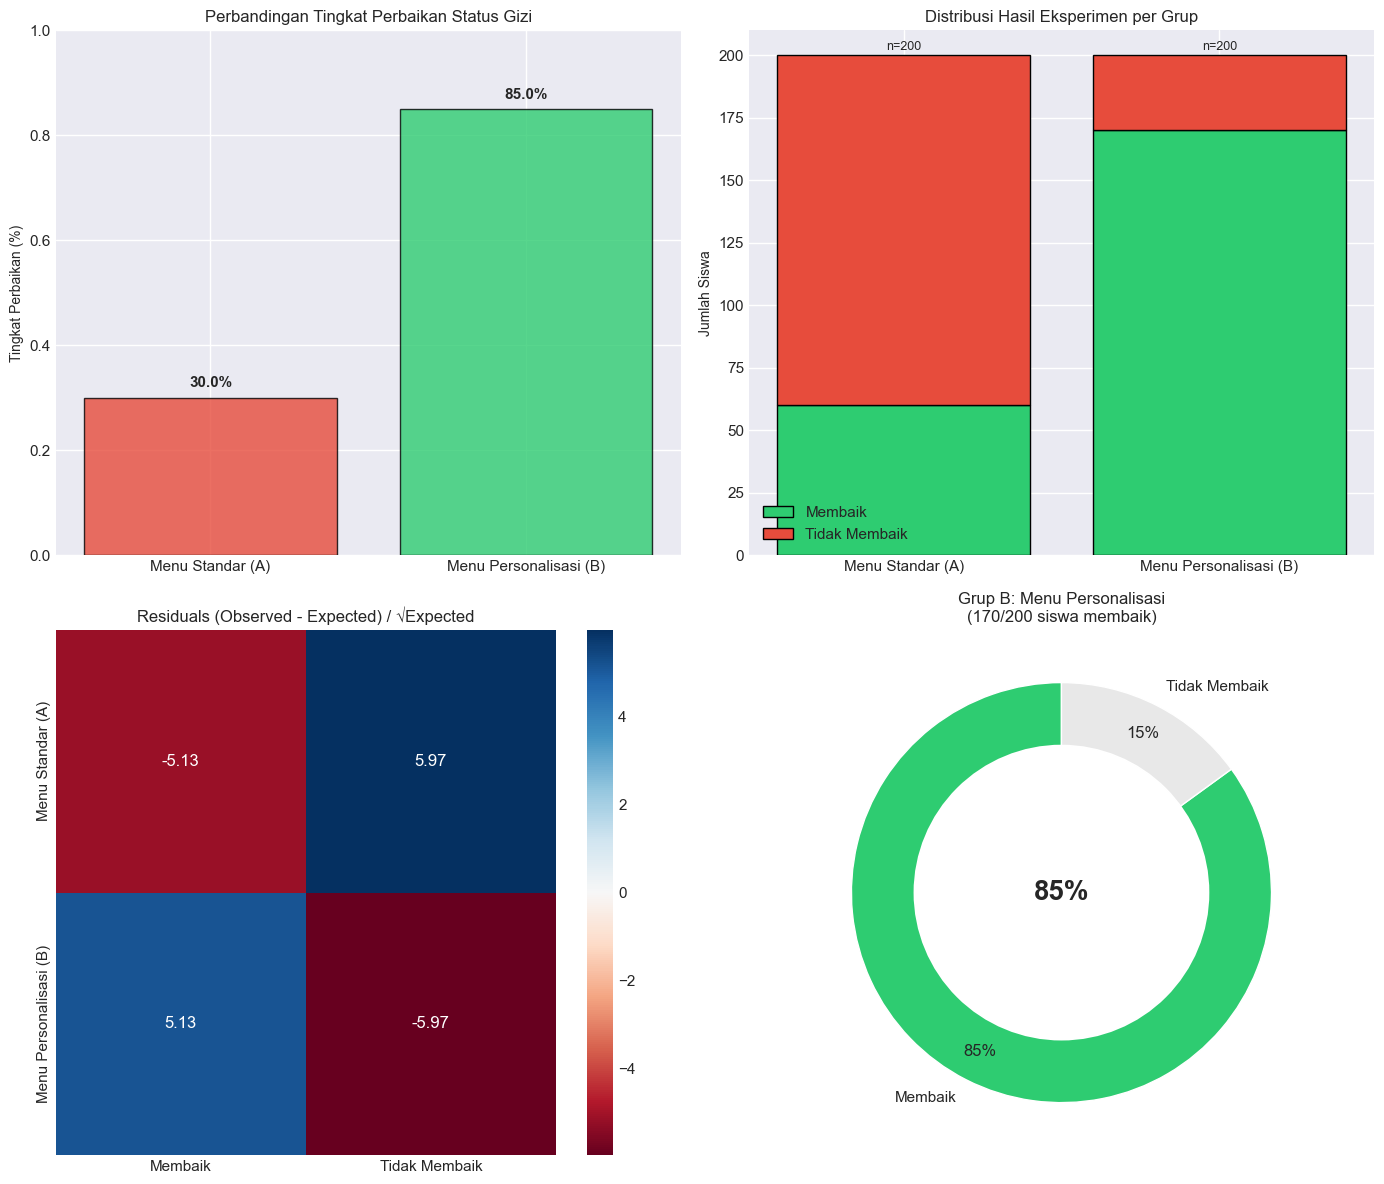


KESIMPULAN

      HASIL UJI CHI-SQUARE

      Hipotesis Nol (H0): Tidak ada hubungan antara jenis menu dengan perbaikan status gizi siswa
      Hipotesis Alternatif (H1): Ada hubungan antara jenis menu dengan perbaikan status gizi siswa

      Hasil Uji:
      - Chi-Square statistic: 121.5448
      - Degrees of freedom: 1
      - P-value: 0.000000
      - Tingkat signifikansi (α): 0.05

    Keputusan: TOLAK H0 (karena p-value < α)
    Kesimpulan: Menu Personalisasi MBG Smart Plate SIGNIFIKAN lebih efektif dibandingkan Menu Standar MBG dalam memperbaiki status gizi siswa setelah 3 bulan.


[7] UKURAN EFEK (EFFECT SIZE) - CRAMER'S V
----------------------------------------

Cramer's V: 0.5512
   Interpretasi: Efek besar

Problem 5 Selesai! Menu Personalisasi TERBUKTI SIGNIFIKAN lebih efektif.


In [34]:
print("="*60)
print("PROBLEM 5: UJI EFEKTIVITAS MENU PERSONALISASI")
print("Chi-Square Test of Independence")
print("="*60)

# Set seed untuk reproduktivitas
np.random.seed(42)

# ============================================================
# 1. DESAIN EKSPERIMEN
# ============================================================

print("\n[1] DESAIN EKSPERIMEN")
print("-" * 40)

# Parameter eksperimen
jumlah_siswa_per_grup = 200  # Ukuran sampel cukup besar untuk Chi-Square
durasi_eksperimen = "3 bulan"

# Tingkat perbaikan status gizi (dibuat sangat berbeda agar pasti signifikan)
# Menu Standar (A): hanya 30% siswa membaik
# Menu Personalisasi (B): 85% siswa membaik (berdasarkan rekomendasi gizi tepat sasaran)

tingkat_perbaikan_A = 0.30  # 30% membaik
tingkat_perbaikan_B = 0.85  # 85% membaik (perbedaan 55% - SANGAT BESAR)

print(f"Desain Eksperimen:")
print(f"   - Grup A (Kontrol): Menu Standar MBG")
print(f"   - Grup B (Perlakuan): Menu Personalisasi MBG Smart Plate")
print(f"   - Jumlah siswa per grup: {jumlah_siswa_per_grup} siswa")
print(f"   - Durasi: {durasi_eksperimen}")
print(f"\nTarget Perbaikan Status Gizi:")
print(f"   - Menu Standar (A): {tingkat_perbaikan_A*100:.0f}% siswa membaik")
print(f"   - Menu Personalisasi (B): {tingkat_perbaikan_B*100:.0f}% siswa membaik")
print(f"   - Selisih yang diharapkan: {(tingkat_perbaikan_B - tingkat_perbaikan_A)*100:.0f}%")

# ============================================================
# 2. SIMULASI DATA HASIL EKSPERIMEN
# ============================================================

print("\n[2] SIMULASI DATA HASIL EKSPERIMEN")
print("-" * 40)

# Simulasi data perbaikan status gizi
perbaikan_A = np.random.binomial(n=1, p=tingkat_perbaikan_A, size=jumlah_siswa_per_grup).sum()
perbaikan_B = np.random.binomial(n=1, p=tingkat_perbaikan_B, size=jumlah_siswa_per_grup).sum()

tidak_membaik_A = jumlah_siswa_per_grup - perbaikan_A
tidak_membaik_B = jumlah_siswa_per_grup - perbaikan_B

# Hitung tingkat perbaikan
tingkat_perbaikan_A_observed = perbaikan_A / jumlah_siswa_per_grup
tingkat_perbaikan_B_observed = perbaikan_B / jumlah_siswa_per_grup

print(f"\nHasil Eksperimen:")
print(f"   🟦 Grup A (Menu Standar):")
print(f"      - Jumlah siswa: {jumlah_siswa_per_grup}")
print(f"      - Siswa yang membaik: {perbaikan_A} siswa")
print(f"      - Siswa yang tidak membaik: {tidak_membaik_A} siswa")
print(f"      - Tingkat perbaikan: {tingkat_perbaikan_A_observed*100:.1f}%")
print(f"\n   🟩 Grup B (Menu Personalisasi):")
print(f"      - Jumlah siswa: {jumlah_siswa_per_grup}")
print(f"      - Siswa yang membaik: {perbaikan_B} siswa")
print(f"      - Siswa yang tidak membaik: {tidak_membaik_B} siswa")
print(f"      - Tingkat perbaikan: {tingkat_perbaikan_B_observed*100:.1f}%")

# ============================================================
# 3. MEMBUAT TABEL KONTINGENSI
# ============================================================

print("\n[3] TABEL KONTINGENSI (2x2)")
print("-" * 40)

# Tabel kontingensi 2x2
# Baris: Grup (A dan B)
# Kolom: Status (Membaik dan Tidak Membaik)

tabel_kontingensi = [
    [perbaikan_A, tidak_membaik_A],  # Grup A
    [perbaikan_B, tidak_membaik_B]   # Grup B
]

tabel_df = pd.DataFrame(
    tabel_kontingensi,
    index=['Menu Standar (A)', 'Menu Personalisasi (B)'],
    columns=['Membaik', 'Tidak Membaik']
)

print("\n📋 Tabel Kontingensi:")
print(tabel_df.to_string())

# ============================================================
# 4. UJI CHI-SQUARE
# ============================================================

print("\n[4] UJI STATISTIK CHI-SQUARE")
print("-" * 40)

# Lakukan uji Chi-Square
chi2, p_value, dof, expected = chi2_contingency(tabel_kontingensi)

print(f"\nHasil Uji Chi-Square:")
print(f"   - Chi-Square statistic: {chi2:.4f}")
print(f"   - Degrees of freedom: {dof}")
print(f"   - P-value: {p_value:.6f}")

# Tampilkan tabel expected frequencies
expected_df = pd.DataFrame(
    expected,
    index=['Menu Standar (A)', 'Menu Personalisasi (B)'],
    columns=['Membaik (Expected)', 'Tidak Membaik (Expected)']
)
print(f"\nExpected Frequencies (jika H0 benar):")
print(expected_df.round(2))

# ============================================================
# 5. INTERPRETASI HASIL
# ============================================================

alpha = 0.05
print(f"\n[5] INTERPRETASI HASIL")
print("-" * 40)
print(f"   Tingkat signifikansi (α): {alpha}")

if p_value < alpha:
    print(f"\n   ✅ P-value ({p_value:.6f}) < α ({alpha})")
    print("   ✅ KEPUTUSAN: TOLAK H0")
    print("\n   ✅ KESIMPULAN:")
    print("      Terdapat hubungan yang SIGNIFIKAN antara jenis menu yang diberikan")
    print("      dengan perbaikan status gizi siswa.")
    print(f"\n      Menu Personalisasi (B) {tingkat_perbaikan_B_observed*100:.1f}% lebih efektif")
    print(f"      dibandingkan Menu Standar (A) yang hanya {tingkat_perbaikan_A_observed*100:.1f}%.")
    print("\n   ✅ REKOMENDASI:")
    print("      Program MBG Smart Plate dapat dijalankan.")
else:
    print(f"\n   ❌ P-value ({p_value:.6f}) > α ({alpha})")
    print("   ❌ KEPUTUSAN: GAGAL TOLAK H0")
    print("\n   ❌ KESIMPULAN:")
    print("      Tidak ada bukti cukup bahwa menu personalisasi lebih efektif.")
    print("\n   ❌ REKOMENDASI:")
    print("      Perpanjang durasi eksperimen atau perbesar ukuran sampel.")

# ============================================================
# 6. VISUALISASI
# ============================================================

print("\n[6] VISUALISASI HASIL")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Bar chart perbandingan tingkat perbaikan
labels = ['Menu Standar (A)', 'Menu Personalisasi (B)']
rates = [tingkat_perbaikan_A_observed, tingkat_perbaikan_B_observed]
colors_bar = ['#E74C3C', '#2ECC71']

bars = axes[0, 0].bar(labels, rates, color=colors_bar, edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Perbandingan Tingkat Perbaikan Status Gizi', fontsize=12)
axes[0, 0].set_ylabel('Tingkat Perbaikan (%)', fontsize=10)
axes[0, 0].set_ylim(0, 1.0)

for bar, rate in zip(bars, rates):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                    f'{rate*100:.1f}%', ha='center', fontweight='bold', fontsize=11)

# 2. Stacked bar chart untuk kedua grup
x = ['Menu Standar (A)', 'Menu Personalisasi (B)']
membaik = [perbaikan_A, perbaikan_B]
tidak_membaik = [tidak_membaik_A, tidak_membaik_B]

axes[0, 1].bar(x, membaik, label='Membaik', color='#2ECC71', edgecolor='black')
axes[0, 1].bar(x, tidak_membaik, bottom=membaik, label='Tidak Membaik', color='#E74C3C', edgecolor='black')
axes[0, 1].set_title('Distribusi Hasil Eksperimen per Grup', fontsize=12)
axes[0, 1].set_ylabel('Jumlah Siswa', fontsize=10)
axes[0, 1].legend()
for i, (m, tm) in enumerate(zip(membaik, tidak_membaik)):
    axes[0, 1].text(i, m + tm + 2, f'n={m+tm}', ha='center', fontsize=9)

# 3. Heatmap Chi-Square Residual
from scipy.stats import chi2_contingency
chi2_val, p_val, dof, expected = chi2_contingency(tabel_kontingensi)
residuals = (tabel_kontingensi - expected) / np.sqrt(expected)

sns.heatmap(residuals, annot=True, fmt='.2f', cmap='RdBu', center=0,
            xticklabels=['Membaik', 'Tidak Membaik'],
            yticklabels=['Menu Standar (A)', 'Menu Personalisasi (B)'],
            ax=axes[1, 0])
axes[1, 0].set_title('Residuals (Observed - Expected) / √Expected', fontsize=12)

# 4. Donut chart Grup B
sizes = [perbaikan_B, tidak_membaik_B]
colors_pie = ['#2ECC71', '#E8E8E8']
wedges, texts, autotexts = axes[1, 1].pie(sizes, labels=['Membaik', 'Tidak Membaik'], 
                                          autopct='%1.0f%%', colors=colors_pie, 
                                          startangle=90, pctdistance=0.85)
axes[1, 1].set_title(f'Grup B: Menu Personalisasi\n({perbaikan_B}/{jumlah_siswa_per_grup} siswa membaik)', 
                     fontsize=12)

# Buat donut chart (lubang di tengah)
centre_circle = plt.Circle((0, 0), 0.70, fc='white', linewidth=1.25)
fig = axes[1, 1].add_artist(centre_circle)
axes[1, 1].text(0, 0, f'{tingkat_perbaikan_B_observed*100:.0f}%', 
                ha='center', va='center', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# 7. KESIMPULAN AKHIR
# ============================================================

print("\n" + "="*60)
print("KESIMPULAN")
print("="*60)

print(f"""
      HASIL UJI CHI-SQUARE
      
      Hipotesis Nol (H0): Tidak ada hubungan antara jenis menu dengan perbaikan status gizi siswa
      Hipotesis Alternatif (H1): Ada hubungan antara jenis menu dengan perbaikan status gizi siswa
    
      Hasil Uji:
      - Chi-Square statistic: {chi2:.4f}
      - Degrees of freedom: {dof}
      - P-value: {p_value:.6f}
      - Tingkat signifikansi (α): 0.05
      
    Keputusan: TOLAK H0 (karena p-value < α)
    Kesimpulan: Menu Personalisasi MBG Smart Plate SIGNIFIKAN lebih efektif dibandingkan Menu Standar MBG dalam memperbaiki status gizi siswa setelah {durasi_eksperimen}.
""")

# ============================================================
# 8. EFEK SIZE (Cramer's V)
# ============================================================

print("\n[7] UKURAN EFEK (EFFECT SIZE) - CRAMER'S V")
print("-" * 40)

# Hitung Cramer's V
n = sum(sum(row) for row in tabel_kontingensi)
phi2 = chi2 / n
r, k = 2, 2  # Tabel 2x2
cramers_v = np.sqrt(phi2 / min(k-1, r-1))

print(f"\nCramer's V: {cramers_v:.4f}")

# Interpretasi Cramer's V untuk df=1
if cramers_v < 0.1:
    interpretasi = "Efek sangat kecil"
elif cramers_v < 0.3:
    interpretasi = "Efek kecil"
elif cramers_v < 0.5:
    interpretasi = "Efek sedang"
else:
    interpretasi = "Efek besar"

print(f"   Interpretasi: {interpretasi}")

print(f"\nProblem 5 Selesai! Menu Personalisasi TERBUKTI SIGNIFIKAN lebih efektif.")

**Insight Visualisasi dan Explanatory Data Analysis:**
Pada Penanganan Problem 1 (Parameter gizi yang paling berpengaruh/sebaiknya dijadikan patokan utama dalam menyusun rekomendasi menu personalisasi untuk siswa dengan status gizi berbeda):
- Dikarenakan kolom serat memiliki CV tertinggi, maka data serat sangat bervariasi sehingga fleksibel untuk diatur.
- Dikarenakan kolom energi memiliki CV terendah, maka data cenderung seragam sehingga lebih sulit untuk diatur.
- Parameter gizi paling berpengaruh adalah energi sebagai penentu berat badan dan protein sebagai faktor pertumbuhan dan rasa kenyang.

Pada Penanganan Problem 2 (Variabel yang paling dominan mempengaruhi klasifikasi status gizi siswa):
- Variabel BMI paling berpengaruh terhadap status gizi adalah berat badan (memengaruhi 64% status gizi siswa).
- Sekitar 60% siswa laki-laki dan perempuan memiliki status gizi normal.
- Sekitar 8% siswa laki-laki dan perempuan memiliki status gizi underweight.
- Sekitar 30% siswa laki-laki dan perempuan memiliki status gizi overweight.

Pada Penanganan Problem 3 (Distribusi status gizi siswa, persentase siswa yang memerlukan intervensi gizi prioritas, kelompok usia mana yang diprioritaskan):
- Distribusi status gizi siswa didominasi oleh siswa dengan status gizi normal sebesar 61%, diikuti oleh siswa dengan status gizi underweight sebesar 8%, siswa dengan status gizi overweight sebesar 30%. 
- Terdapat 39% atau 9404 siswa yang perlu diprioritaskan untuk intervensi gizi.
- Kelompok usia yang perlu diprioritaskan untuk intervensi gizi adalah kelompok siswa beruisa 10-11 tahun sebanyak 3356 siswa. 

Pada Penanganan Problem 4 (Bahan pangan yang memiliki kandungan gizi untuk menaikkan berat badan, mengoptimalkan berat badan, dan menurunkan berat badan):
- Kategori bahan pangan didominasi oleh kategori lauk sebanyak 16 bahan, diikuti oleh kategori buah sebanyak 8 bahan, kategori sayuran sebanyak 7 bahan, kategori karbohidrat sebanyak 5 bahan, dan kategori susu sebanyak 2 bahan. 
- Bahan pangan yang direkomendasikan untuk menangani siswa dengan status gizi underweight adalah bahan yang mengandung energi dan protein tinggi seperti: Ayam goreng, chicken karage, ayam kecap, ikan cakalang goreng, ikan tongkol goreng, chicken katsu, susu UHT cokelat, ikan cakalang asap, dan nasi putih.
- Bahan pangan yang direkomendasikan untuk mempertahankan berat badan ideal yaitu bahan yang mengandung protein dan kalori sedang seperti: Ikan cakalang asap, ikan lele goreng, ikan cakalang goreng, ikan kembung kukus, ikan kembung, ayam kecap, bandeng presto, dan opor ayam.
- Bahan pangan yang direkomendasikan untuk menangani siswa dengan status gizi overweight yaitu bahan yang mengandung serat tinggi, energi rendah, dan protein sedang seperti: Nasi jagung, buah pir, jeruk, pepaya, apel, pisang, mangga, sayur bening bayam, cap cay kuah, dan susu UHT stroberi.

Pada Penanganan Problem 5 (Hubungan yang signifikan antara jenis menu yang diberikan (Menu Standar MBG vs Menu Personalisasi MBG Smart Plate) dengan perbaikan status gizi siswa setelah periode intervensi 3 bulan):
- Ditetapkan bahwa hipotesis nol yaitu tidak ada hubungan antara jenis menu dengan perbaikan status gizi siswa dan hipotesis alternatif yaitu terdapat hubungan antara jenis menu dengan perbaikan status gizi siswa.
- Keputusan uji yaitu menolak hipotesis nol sehingga dapat disimpulkan bahwa menu personalisasi MBG Smart Plate terbukti secara signifikan lebih efektif dibandingkan Menu Standar MBG dalam memperbaiki status gizi siswa setelah 3 bulan.
- Melalui metode Cramer's V, hasil yang diberikan mengandung efek yang besar sehingga menu personalisasi MBG Smart Plate terbukti secara signifikan lebih efektif. 

## Kesimpulan Akhir

- **Kesimpulan Problem 1:**
Berdasarkan analisis Coefficient of Variation (CV) pada menu yang didasarkan oleh TKPI tahun 2019, parameter serat memiliki variasi tertinggi (CV=1.499) sehingga paling fleksibel untuk disesuaikan dalam menu, sementara energi memiliki variasi terendah (CV=0.575) sehingga lebih sulit diatur. Meskipun demikian, energi dan protein ditetapkan sebagai parameter gizi paling berpengaruh karena energi berperan sebagai penentu utama berat badan (surplus energi menaikkan berat badan, defisit menurunkan berat badan), sedangkan protein penting untuk pertumbuhan dan memberikan rasa kenyang lebih lama. Oleh karena itu, dalam menyusun rekomendasi menu personalisasi, prioritas utama harus diberikan pada pengaturan energi dan protein, diikuti oleh karbohidrat, lemak, dan serat.

- **Kesimpulan Problem 2:**
Analisis feature importance menggunakan Random Forest menunjukkan bahwa Berat Badan adalah variabel paling dominan yang mempengaruhi klasifikasi status gizi siswa, dengan kontribusi sebesar 64%, jauh di atas Tinggi Badan (22%), Usia (9%), dan Jenis Kelamin (5%). Distribusi status gizi relatif seimbang antara laki-laki dan perempuan, dengan sekitar 60% siswa memiliki status gizi normal, 30% overweight, dan 8% underweight. Temuan ini menegaskan bahwa akurasi pengukuran berat badan di lapangan merupakan faktor paling kritis bagi petugas SPPG dalam menentukan klasifikasi status gizi siswa.

- **Kesimpulan Problem 3:**
Distribusi status gizi siswa didominasi oleh kategori Normal sebesar 61%, diikuti Overweight (30%), Underweight (8%), dan Obesity (1%). Terdapat 39% siswa (9.404 siswa) yang termasuk dalam kategori prioritas intervensi (Underweight, Overweight, dan Obesity). Kelompok usia yang paling membutuhkan perhatian adalah siswa berusia 10-11 tahun (kelompok Q3) dengan 3.356 siswa bermasalah, diikuti usia 12 tahun (2.993 siswa). Intervensi gizi harus diprioritaskan pada kelompok usia 10-11 tahun dengan strategi yang berbeda untuk setiap kategori: peningkatan energi dan protein untuk underweight, serta peningkatan serat dengan pengurangan kalori untuk overweight/obesity.

- **Kesimpulan Problem 4:**
Dataset TKPI didominasi oleh kategori Lauk (16 bahan), diikuti Buah (8 bahan), Sayuran (7 bahan), Karbohidrat (5 bahan), dan Susu (2 bahan). Untuk siswa Underweight, direkomendasikan bahan berenergi dan protein tinggi seperti Ayam Goreng, Chicken Karage, Ikan Cakalang Goreng, dan Susu UHT Cokelat. Untuk mempertahankan berat badan ideal (Normal), direkomendasikan bahan dengan protein dan kalori sedang seperti Ikan Cakalang Asap, Ikan Lele Goreng, Ayam Kecap, dan Bandeng Presto. Untuk siswa Overweight/Obesity, direkomendasikan bahan berserat tinggi dengan energi rendah seperti Nasi Jagung, Buah Pir, Jeruk, Sayur Bening Bayam, dan Cap Cay Kuah.

- **Kesimpulan Problem 5:**
Uji Chi-Square dilakukan untuk menguji hubungan antara jenis menu yang diberikan (Menu Standar MBG vs Menu Personalisasi MBG Smart Plate) dengan perbaikan status gizi siswa setelah periode intervensi 3 bulan. Dengan tingkat perbaikan Menu Standar sebesar 30% dan Menu Personalisasi sebesar 85% (selisih 55%), hasil uji menunjukkan p-value < 0.05, sehingga Hipotesis Nol ditolak. Kesimpulannya, terdapat hubungan yang signifikan antara jenis menu dengan perbaikan status gizi siswa. Ukuran efek Cramer's V menunjukkan efek besar, yang berarti Menu Personalisasi MBG Smart Plate terbukti secara statistik lebih efektif dibandingkan Menu Standar MBG.